# Altered vs Valid DPA Comparison



In [ ]:
from pathlib import Path
import os
import re

import numpy as np
import pandas as pd

from ANALYSIS_HW_HD_utils import *
from ANALYSIS_plots_utils import *
from ANALYSIS_create_npy_file import create_npy_file_truncated
from reset_folder_notebook import reset_folder
from concurrent.futures import ThreadPoolExecutor, as_completed

selected_fault_index = 0
no_instructions = 100
result_dir_truncated = "Results_decapsulation_truncated_differentS"
os.makedirs(result_dir_truncated, exist_ok=True)
reset_folder(result_dir_truncated)

B_folder = Path("output_decapsulation_truncated/B")
S_path_default = Path("output_decapsulation_truncated/S/S.csv")
if S_path_default.exists():
    S_df = pd.read_csv(S_path_default)
    S_real = S_df[[f"S_col_{j}" for j in range(8)]].to_numpy(dtype=np.int16)
else:
    print(f"[WARNING] Missing {S_path_default}; cells that evaluate against S_real need this file.")

# Empirical valid-vs-altered comparison paths
TRACE_COUNTS = [5, 10, 20, 40, 80]
PAIR_COUNTS = [4, 8, 16, 32, 64, 128]
XS_IDS = range(8)

EMPIRICAL_OUTPUT_DIR = Path("output_decapsulation_empirical")
ALTERED_OUTPUT_DIR = EMPIRICAL_OUTPUT_DIR
ALTERED_B_DIR = ALTERED_OUTPUT_DIR / "B"
ALTERED_S_DIR = ALTERED_OUTPUT_DIR / "S"
ALTERED_B_PREFIX = "B_from_registers_packed"

VALID_OUTPUT_DIR = EMPIRICAL_OUTPUT_DIR
VALID_B_DIR = VALID_OUTPUT_DIR / "B"
VALID_S_DIR = VALID_OUTPUT_DIR / "S"
VALID_B_PREFIX = "B_valid_from_registers_packed"

RESULT_DIR = Path("Results_valid_vs_altered_empirical")
RESULT_DIR.mkdir(exist_ok=True)

THRESHOLD = 0.998
COMPARISON_JOBS = 10



Utility functions to load B matrices, S matrices, and traces for the same fixed fault index

In [52]:
def load_B(run_index, B_folder, prefix="B", fault_index=None, random_index=None):
    """Load one B matrix from a CSV file."""
    B_folder = Path(B_folder)
    random_suffix = "" if random_index is None else f"_random{random_index}"

    if fault_index is None:
        path = B_folder / f"{prefix}_{run_index}{random_suffix}.csv"
    else:
        path = B_folder / f"{prefix}_{run_index}_{fault_index}{random_suffix}.csv"

    if not path.exists():
        raise FileNotFoundError(f"Missing B file: {path}")

    df = pd.read_csv(path)
    value_cols = [col for col in df.columns if col != "row"]
    return df[value_cols].to_numpy(dtype=np.float64)


def load_all_B(B_folder, prefix="B", fault_index=None):
    """Load all B matrices matching a prefix and optional fixed fault index"""
    if fault_index is None:
        pattern = re.compile(rf"{re.escape(prefix)}_(\d+)\.csv$")
    else:
        pattern = re.compile(rf"{re.escape(prefix)}_(\d+)_{fault_index}\.csv$")

    files = []
    for path in Path(B_folder).glob(f"{prefix}_*.csv"):
        match = pattern.fullmatch(path.name)
        if match is not None:
            files.append((int(match.group(1)), path))

    files.sort(key=lambda item: item[0])

    if not files:
        suffix = "" if fault_index is None else f" for fault_index={fault_index}"
        raise FileNotFoundError(f"No {prefix}_*.csv files found in {B_folder}{suffix}")

    runs = [run_index for run_index, _ in files]
    B_all = np.array([
        load_B(run_index, B_folder, prefix=prefix, fault_index=fault_index)
        for run_index in runs
    ])
    return B_all, runs


def trace_path_for_mode(output_dir_trim, run_index, xs_id, fault_index=None, mode="modified", random_index=None):
    """Build the trace CSV path for valid, and modified traces"""
    output_dir_trim = Path(output_dir_trim)
    random_suffix = "" if random_index is None else f"_random{random_index}"

    if mode == "valid":
        return output_dir_trim / f"trace_valid_{run_index}_{xs_id}{random_suffix}.csv"

    if mode == "modified":
        if fault_index is None:
            raise ValueError("fault_index is required for modified traces")
        return output_dir_trim / f"trace_{run_index}_{xs_id}_{fault_index}{random_suffix}.csv"

    raise ValueError(f"Unknown mode: {mode}")


def load_hw_r0_for_fault(xs_id, fault_index, run_order, output_dir_trim="output_decapsulation_truncated_TRIM", mode="modified", random_indices=None):
    """Load r0 HW traces for the same fixed fault index because the result is stored in r0"""
    traces = []

    if random_indices is None:
        random_indices = [None] * len(run_order)
    if len(random_indices) != len(run_order):
        raise ValueError("random_indices must be None or have the same length as run_order")

    for run_index, random_index in zip(run_order, random_indices):
        trace_path = trace_path_for_mode(
            output_dir_trim,
            run_index,
            xs_id,
            fault_index=fault_index,
            mode=mode,
            random_index=random_index,
        )

        if not trace_path.exists():
            raise FileNotFoundError(f"Missing trace: {trace_path}")

        traces.append(create_HW_trace(trace_path, ["r0"]))

    min_len = min(len(trace) for trace in traces)
    return np.array([trace[:min_len] for trace in traces])

def load_combined_modified_base_inputs(B_folder, B_PREFIX, fault_indices, base_fault_index=None, max_runs=None):
    """Load all B matrices for all requested fault indices"""
    all_needed_faults = sorted(set(fault_indices) | {base_fault_index})
    B_by_fault = {}
    runs_by_fault = {}

    for fault_index in all_needed_faults:
        B_by_fault[fault_index], runs_by_fault[fault_index] = load_all_B(B_folder, prefix=B_PREFIX, fault_index=fault_index)

    selected_runs = list(runs_by_fault[base_fault_index])
    if max_runs is not None:
        selected_runs = selected_runs[:max_runs]

    no_selected_runs = len(selected_runs)
    B_by_fault = {
        fault_index: B_by_fault[fault_index][:no_selected_runs]
        for fault_index in all_needed_faults
    }

    return B_by_fault, selected_runs


def available_different_S_runs_and_randoms(trace_dir=None):
    trace_dir = Path(trace_dir or DIFFERENT_S_TRACE_DIR)
    pattern = re.compile(r"trace_(\d+)_0_0_random(\d+)\.csv$")
    runs = {}
    for path in trace_dir.glob("trace_*_0_0_random*.csv"):
        match = pattern.fullmatch(path.name)
        if match is None:
            continue
        run_index = int(match.group(1))
        random_index = int(match.group(2))
        runs.setdefault(run_index, set()).add(random_index)
    return {run: sorted(randoms) for run, randoms in sorted(runs.items())}


def available_valid_per_S_runs_and_randoms(trace_dir=None):
    trace_dir = Path(trace_dir or VALID_PER_S_TRACE_DIR)
    pattern = re.compile(r"trace_valid_(\d+)_0_random(\d+)\.csv$")
    runs = {}

    for path in trace_dir.glob("trace_valid_*_0_random*.csv"):
        match = pattern.fullmatch(path.name)
        if match is None:
            continue
        run_index = int(match.group(1))
        random_index = int(match.group(2))
        runs.setdefault(run_index, set()).add(random_index)

    return {run: sorted(randoms) for run, randoms in sorted(runs.items())}


def load_different_S_matrix(run_index, fault_index=None, random_index=None, S_folder=None):
    S_folder = Path(S_folder or DIFFERENT_S_S_FOLDER)
    candidates = []
    if fault_index is not None and random_index is not None:
        candidates.append(S_folder / f"S_{run_index}_{fault_index}_random{random_index}.csv")
    if random_index is not None:
        candidates.append(S_folder / f"S_valid_{run_index}_random{random_index}.csv")
        candidates.append(S_folder / f"S_{run_index}_random{random_index}.csv")
    candidates.extend([
        S_folder / f"S_{run_index}.csv",
        S_folder / f"S_valid_{run_index}.csv",
    ])

    for path in candidates:
        if path.exists():
            S_df = pd.read_csv(path)
            return S_df[[f"S_col_{j}" for j in range(8)]].to_numpy(dtype=np.int16), path

    raise FileNotFoundError(
        f"No S matrix found for run={run_index}, fault={fault_index}, random={random_index}. Tried: "
        + ", ".join(str(path) for path in candidates)
    )


Function to find the instruction index of the smlad instruction that processes a given B row and pair index

In [53]:
def smlad_hw_index(xs_id, b_row, pair_idx, fault_index, reference_run=0, output_dir_trim="output_decapsulation_truncated_TRIM", mode="modified", random_index=None):
    trace_path = trace_path_for_mode( output_dir_trim, reference_run, xs_id, fault_index=fault_index, mode=mode, random_index=random_index)
    trace_path = Path(trace_path)
    if not trace_path.exists():
        raise FileNotFoundError(f"Missing trace: {trace_path}")

    trace_df = pd.read_csv(trace_path)
    trace_df["instruction"] = trace_df["instruction"].astype(str).str.strip().str.lower()
    smlad_indices = trace_df.index[trace_df["instruction"] == "smlad"].to_numpy()

    smlads_per_xs_call = 320
    smlad_global_idx = b_row * smlads_per_xs_call + pair_idx
    if smlad_global_idx >= len(smlad_indices):
        raise IndexError(
            f"smlad_global_idx={smlad_global_idx} is outside {len(smlad_indices)} smlad instructions "
            f"for trace={trace_path}"
        )

    return int(smlad_indices[smlad_global_idx]) + 1


def trace_window_at_hw_index(traces_hw, hw_index, instructions_before=0, instructions_after=10):
    start = max(0, hw_index - instructions_before)
    end = min(traces_hw.shape[1], hw_index + instructions_after + 1)
    return traces_hw[:, start:end], hw_index - start


## CPA Attack 


### Helpers

In [54]:
FAULT_INDICES_FOR_PAIRS = list(range(0, 320, 2))
S_GUESSES = range(-10, 11)
ATTACK_B_PREFIX = "B_from_registers_packed"

Calculate the score of the pair

In [55]:
def unpack_i16_pair_from_u32(x):
    x = np.asarray(x, dtype=np.uint32)
    low = (x & 0xffff).astype(np.int32)
    high = ((x >> 16) & 0xffff).astype(np.int32)

    low = np.where(low >= 0x8000, low - 0x10000, low)
    high = np.where(high >= 0x8000, high - 0x10000, high)
    return low, high


def packed_pair_values(B_values, b_row, pair_idx):
    B_packed = B_values[:, b_row, pair_idx]
    return unpack_i16_pair_from_u32(B_packed)


def assert_previous_packed_pairs_zero(B_values, b_row, pair_idx, fault_index=None, label="B'"):
    if fault_index is not None and fault_index != 2 * pair_idx:
        raise ValueError(
            f"{label}: fault_index={fault_index} does not isolate pair_idx={pair_idx}; "
            f"expected fault_index={2 * pair_idx}"
        )

    if pair_idx == 0:
        return

    previous_pairs = np.asarray(B_values[:, b_row, :pair_idx], dtype=np.uint32)
    nonzero_positions = np.argwhere(previous_pairs != 0)
    if nonzero_positions.size == 0:
        return

    run_pos, previous_pair_idx = nonzero_positions[0]
    raise ValueError(
        f"{label}: previous packed pair columns are not zero for b_row={b_row}, "
        f"target_pair_idx={pair_idx}, previous_pair_idx={int(previous_pair_idx)}, "
        f"run_position={int(run_pos)}, value={int(previous_pairs[run_pos, previous_pair_idx])}"
    )


def B_pair_detail_values(B_values, b_row, pair_idx):
    B_i, B_j = packed_pair_values(B_values, b_row, pair_idx)
    return {
        "B_pair": " ".join(f"({int(b_i)},{int(b_j)})" for b_i, b_j in zip(B_i, B_j)),
    }


def format_B_pair_values(B_values, b_row, pair_idx):
    B_pair = B_pair_detail_values(B_values, b_row, pair_idx)["B_pair"]
    no_traces = 0 if B_pair == "" else len(B_pair.split())
    return f"B_pair={B_pair}; no_traces={no_traces}"


def score_candidate(candidate, B_values, b_row, pair_idx, r0_old, traces_hw, hw_local_index):
    B_packed = B_values[:, b_row, pair_idx]
    B0, B1 = unpack_i16_pair_from_u32(B_packed)

    pair_product = B0 * int(candidate["S0"]) + B1 * int(candidate["S1"])
    r0_guess = r0_old + pair_product
    target_hw = hw_u32(r0_guess & 0xffffffff)
    corr = compute_correlation(traces_hw, target_hw)[hw_local_index]
    return corr, pair_product


def rank_of_true_pair(scores, S0_true, S1_true):
    for rank, row in enumerate(scores, start=1):
        if (row["S0"], row["S1"]) == (S0_true, S1_true):
            return rank
    return np.nan


def find_candidate(scores, S0_guess, S1_guess):
    for rank, row in enumerate(scores, start=1):
        if (row["S0"], row["S1"]) == (S0_guess, S1_guess):
            return rank, row
    return np.nan, {"S0": int(S0_guess), "S1": int(S1_guess), "corr": np.nan, "pair_product": None}


def rank_of_candidate(scores, S0_guess, S1_guess):
    rank, _ = find_candidate(scores, S0_guess, S1_guess)
    return rank


def score_all_pair_guesses(B_values, b_row, pair_idx, r0_old, traces_window, hw_local_index, S_guesses):
    scores = []
    for S0_guess in S_guesses:
        for S1_guess in S_guesses:
            candidate = {"S0": int(S0_guess), "S1": int(S1_guess)}
            corr, pair_product = score_candidate(candidate, B_values, b_row, pair_idx, r0_old, traces_window, hw_local_index)
            scores.append({
                **candidate,
                "corr": corr,
                "pair_product": pair_product,
            })

    scores.sort(key=lambda row: abs(row["corr"]), reverse=True)
    return scores


Run the attack with the acummulator produced by the guessed pairs

In [56]:
def run_packed_accumulator_attack(attack_label, pair_items, run_order, load_B_for_pair, trace_mode, b_col_for_pair, fault_index_for_trace, rank_output_filename, xs_ids=range(8), S_guesses=S_GUESSES, instructions_before=0, instructions_after=10, accumulate=True):
    recovered = np.empty((8, len(pair_items)), dtype=object)
    true_values = np.empty((8, len(pair_items)), dtype=object)
    true_ranks = np.full((8, len(pair_items)), np.nan)
    details = []

    for xs_id in xs_ids:
        b_row = xs_id
        r0_old = np.zeros(len(run_order), dtype=np.int32)
        print(f"{attack_label} xs_id={xs_id}")

        for col_idx, pair_item in enumerate(pair_items):
            pair_idx = col_idx if trace_mode == "modified" else pair_item
            fault_index = fault_index_for_trace(pair_item, col_idx)
            b_col = b_col_for_pair(pair_item, col_idx)
            B_values = load_B_for_pair(pair_item, col_idx)

            if not accumulate:
                r0_old = np.zeros(len(run_order), dtype=np.int32)

            if trace_mode == "modified" and not accumulate:
                assert_previous_packed_pairs_zero(
                    B_values,
                    b_row,
                    pair_idx,
                    fault_index=fault_index,
                    label=f"{attack_label} xs_id={xs_id} pair={pair_idx}",
                )

            hw_index = smlad_hw_index(xs_id=xs_id, b_row=b_row, pair_idx=pair_idx, fault_index=fault_index, reference_run=run_order[0], mode=trace_mode)
            traces_hw = load_hw_r0_for_fault(xs_id, fault_index, run_order, mode=trace_mode)
            traces_window, hw_local_index = trace_window_at_hw_index(traces_hw, hw_index, instructions_before=instructions_before, instructions_after=instructions_after)

            scores = score_all_pair_guesses(B_values, b_row, pair_idx, r0_old, traces_window, hw_local_index, S_guesses)
            best = scores[0]
            best_S0, best_S1 = best["S0"], best["S1"]

            if accumulate:
                r0_old = r0_old + best["pair_product"]

            S0_true = int(S_real[b_col, xs_id])
            S1_true = int(S_real[b_col + 1, xs_id])
            true_rank = rank_of_true_pair(scores, S0_true, S1_true)

            recovered[xs_id, col_idx] = f"({best_S0},{best_S1})"
            true_values[xs_id, col_idx] = f"({S0_true},{S1_true})"
            true_ranks[xs_id, col_idx] = true_rank

            detail = {
                "xs_id": xs_id,
                "pair_idx": pair_idx,
                "S_true": f"({S0_true},{S1_true})",
                "S_guessed": f"({best_S0},{best_S1})",
                "S_rank": true_rank,
                "correlation_score": best["corr"],
            }
            if fault_index is not None:
                detail["fault_index"] = fault_index
            details.append(detail)

            fault_text = "" if fault_index is None else f", fault={fault_index}"
            print(
                f"pair={pair_idx}{fault_text}, best=({best_S0},{best_S1}), "
                f"true=({S0_true},{S1_true}), rank={true_rank}"
            )

    pair_columns = [f"S_pair_{pair_item}" for pair_item in pair_items]
    recovered_df = pd.DataFrame(recovered, columns=pair_columns)
    true_df = pd.DataFrame(true_values, columns=pair_columns)
    rank_df = pd.DataFrame(true_ranks, columns=pair_columns)
    details_df = pd.DataFrame(details)

    for df in [recovered_df, true_df, rank_df]:
        df.index.name = "xs_id"

    os.makedirs(result_dir_truncated, exist_ok=True)
    rank_df.to_csv(os.path.join(result_dir_truncated, rank_output_filename))

    success_rate = np.count_nonzero(true_ranks == 1) / np.count_nonzero(~np.isnan(true_ranks))
    print(f"{attack_label} success rate with {len(run_order)} traces: {success_rate:.2%}")

    return recovered_df, rank_df, details_df


### DPA Altered Ciphertext - independent guesses (without context check)

In [57]:
def accumulator_attack(xs_ids=range(8), fault_indices=FAULT_INDICES_FOR_PAIRS, S_guesses=S_GUESSES, instructions_before=0, instructions_after=10, max_runs=None):
    B_by_fault = {}
    runs_by_fault = {}
    for fault_index in fault_indices:
        B_by_fault[fault_index], runs_by_fault[fault_index] = load_all_B(
            B_folder,
            prefix=ATTACK_B_PREFIX,
            fault_index=fault_index,
        )

    all_runs = runs_by_fault[fault_indices[0]]
    for fault_index in fault_indices[1:]:
        if runs_by_fault[fault_index] != all_runs:
            raise ValueError(f"Run order mismatch for fault_index={fault_index}")

    if max_runs is None:
        selected_positions = np.arange(len(all_runs))
    else:
        selected_positions = np.arange(min(max_runs, len(all_runs)))

    selected_runs = [all_runs[pos] for pos in selected_positions]

    recovered_df, rank_df, details_df = run_packed_accumulator_attack(
        attack_label="altered",
        pair_items=fault_indices,
        run_order=selected_runs,
        load_B_for_pair=lambda fault_index, pair_idx: B_by_fault[fault_index][selected_positions],
        trace_mode="modified",
        b_col_for_pair=lambda fault_index, pair_idx: fault_index,
        fault_index_for_trace=lambda fault_index, pair_idx: fault_index,
        rank_output_filename="Rank_S_modified_accumulator_HW.csv",
        xs_ids=xs_ids,
        S_guesses=S_guesses,
        instructions_before=instructions_before,
        instructions_after=instructions_after,
        accumulate=False,
    )

    wrong_rows = []
    for row in details_df.itertuples(index=False):
        if row.S_rank == 1:
            continue
        B_values = B_by_fault[row.fault_index][selected_positions]
        wrong_rows.append({
            "xs_id": row.xs_id,
            "pair_idx": row.pair_idx,
            "fault_index": row.fault_index,
            "S_guessed": row.S_guessed,
            "S_true": row.S_true,
            "S_rank": row.S_rank,
            "correlation_score": row.correlation_score,
            **B_pair_detail_values(B_values, row.xs_id, row.pair_idx),
        })

    wrong_pairs_df = pd.DataFrame(wrong_rows)
    wrong_pairs_path = os.path.join(result_dir_truncated, "wrong_pairs_altered_independent_B_values.csv")
    wrong_pairs_df.to_csv(wrong_pairs_path, index=False)
    print(f"Saved wrong altered-independent pairs with B values to {wrong_pairs_path}")

    return recovered_df, rank_df


recovered_modified_df, rank_modified_df = accumulator_attack()


altered xs_id=0
pair=0, fault=0, best=(3,-3), true=(3,-3), rank=1
pair=1, fault=2, best=(0,1), true=(0,1), rank=1
pair=2, fault=4, best=(-10,-6), true=(-5,-3), rank=2
pair=3, fault=6, best=(-6,-2), true=(-3,-1), rank=2
pair=4, fault=8, best=(3,2), true=(3,2), rank=1
pair=5, fault=10, best=(-10,-10), true=(0,0), rank=221
pair=6, fault=12, best=(-2,2), true=(-2,2), rank=1
pair=7, fault=14, best=(-3,3), true=(-3,3), rank=1
pair=8, fault=16, best=(-6,-1), true=(-6,-1), rank=1
pair=9, fault=18, best=(-3,4), true=(-3,4), rank=1
pair=10, fault=20, best=(-4,5), true=(-4,5), rank=1
pair=11, fault=22, best=(-3,7), true=(-3,7), rank=1
pair=12, fault=24, best=(-1,1), true=(-1,1), rank=1
pair=13, fault=26, best=(0,-8), true=(0,-1), rank=4
pair=14, fault=28, best=(4,1), true=(4,1), rank=1
pair=15, fault=30, best=(1,1), true=(2,2), rank=2
pair=16, fault=32, best=(0,-8), true=(0,-1), rank=4
pair=17, fault=34, best=(-2,2), true=(-2,2), rank=1
pair=18, fault=36, best=(7,-1), true=(7,-1), rank=1
pair=19,

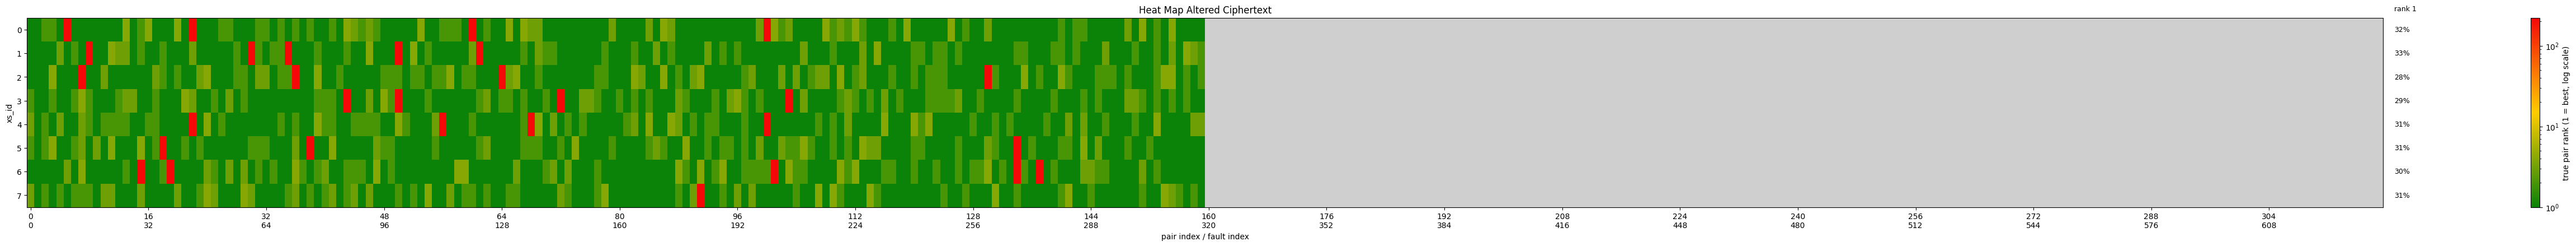

Saved rank heatmap to Results_decapsulation_truncated_differentS/heatmap_altered_ciphertext.png
Rank summary:
count    1280.000000
mean        6.725781
std        33.219797
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max       221.000000
dtype: float64


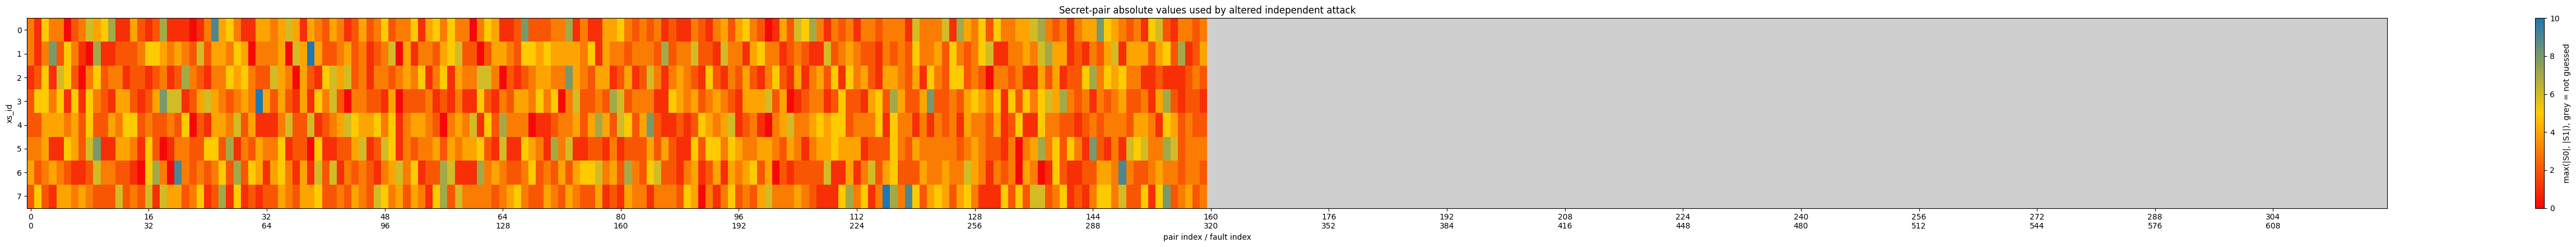

Saved secret-pair absolute-value heatmap to Results_decapsulation_truncated_differentS/heatmap_S_abs_altered_independent.png


In [58]:
def rank_df_to_full_S_pairs(rank_df, S_matrix):
    no_pairs_total = S_matrix.shape[0] // 2
    full_rank_df = pd.DataFrame(
        np.nan,
        index=rank_df.index,
        columns=[f"S_pair_{pair_idx}" for pair_idx in range(no_pairs_total)],
    )
    guessed_pair_indices = []

    for column in rank_df.columns:
        fault_index = int(str(column).replace("S_pair_", ""))
        pair_idx = fault_index // 2
        if pair_idx >= no_pairs_total:
            continue
        full_rank_df[f"S_pair_{pair_idx}"] = rank_df[column]
        guessed_pair_indices.append(pair_idx)

    return full_rank_df, sorted(set(guessed_pair_indices))


rank_modified_full_df, altered_independent_guessed_pairs = rank_df_to_full_S_pairs(rank_modified_df, S_real)

rank_modified_heatmap_path = plot_rank_heatmap(
    rank_modified_full_df,
    title="Heat Map Altered Ciphertext",
    save_path=os.path.join(
        result_dir_truncated,
        "heatmap_altered_ciphertext.png",
    ),
)

S_abs_heatmap_path = plot_secret_pair_abs_heatmap(
    S_real,
    title="Secret-pair absolute values used by altered independent attack",
    save_path=os.path.join(
        result_dir_truncated,
        "heatmap_S_abs_altered_independent.png",
    ),
    pair_indices=altered_independent_guessed_pairs,
)


### DPA Attack With Valid B - progresssive guesses 


In [59]:
VALID_PAIR_INDICES = list(range(160))
VALID_B_PREFIX = "B_valid_from_registers_packed"

In [60]:
def accumulator_attack_valid(xs_ids=range(8), pair_indices=VALID_PAIR_INDICES, S_guesses=S_GUESSES, instructions_before=0, instructions_after=10, max_runs=None):
    B_valid_packed, valid_runs = load_all_B(B_folder, prefix=VALID_B_PREFIX)

    if max_runs is not None:
        valid_runs = valid_runs[:max_runs]
        B_valid_packed = B_valid_packed[:len(valid_runs)]

    return run_packed_accumulator_attack( attack_label="valid", pair_items=pair_indices, run_order=valid_runs, load_B_for_pair=lambda pair_idx, col_idx: B_valid_packed, trace_mode="valid", b_col_for_pair=lambda pair_idx, col_idx: 2 * pair_idx, fault_index_for_trace=lambda pair_idx, col_idx: None, rank_output_filename="Rank_S_accumulator_HW_valid.csv", xs_ids=xs_ids, S_guesses=S_guesses, instructions_before=instructions_before, instructions_after=instructions_after, accumulate=True)


recovered_valid_df, rank_valid_df, details_valid_df = accumulator_attack_valid()


valid xs_id=0
pair=0, best=(3,-3), true=(3,-3), rank=1
pair=1, best=(0,1), true=(0,1), rank=1
pair=2, best=(-5,-3), true=(-5,-3), rank=1
pair=3, best=(-3,-1), true=(-3,-1), rank=1
pair=4, best=(3,2), true=(3,2), rank=1
pair=5, best=(0,0), true=(0,0), rank=1
pair=6, best=(-2,2), true=(-2,2), rank=1
pair=7, best=(-3,3), true=(-3,3), rank=1
pair=8, best=(-6,-1), true=(-6,-1), rank=1
pair=9, best=(-3,4), true=(-3,4), rank=1
pair=10, best=(-4,5), true=(-4,5), rank=1
pair=11, best=(-3,7), true=(-3,7), rank=1
pair=12, best=(-1,1), true=(-1,1), rank=1
pair=13, best=(0,-1), true=(0,-1), rank=1
pair=14, best=(4,1), true=(4,1), rank=1
pair=15, best=(2,2), true=(2,2), rank=1
pair=16, best=(0,-1), true=(0,-1), rank=1
pair=17, best=(-2,2), true=(-2,2), rank=1
pair=18, best=(7,-1), true=(7,-1), rank=1
pair=19, best=(1,1), true=(1,1), rank=1
pair=20, best=(-1,-1), true=(-1,-1), rank=1
pair=21, best=(1,0), true=(1,0), rank=1
pair=22, best=(0,0), true=(0,0), rank=1
pair=23, best=(0,1), true=(0,1), rank=

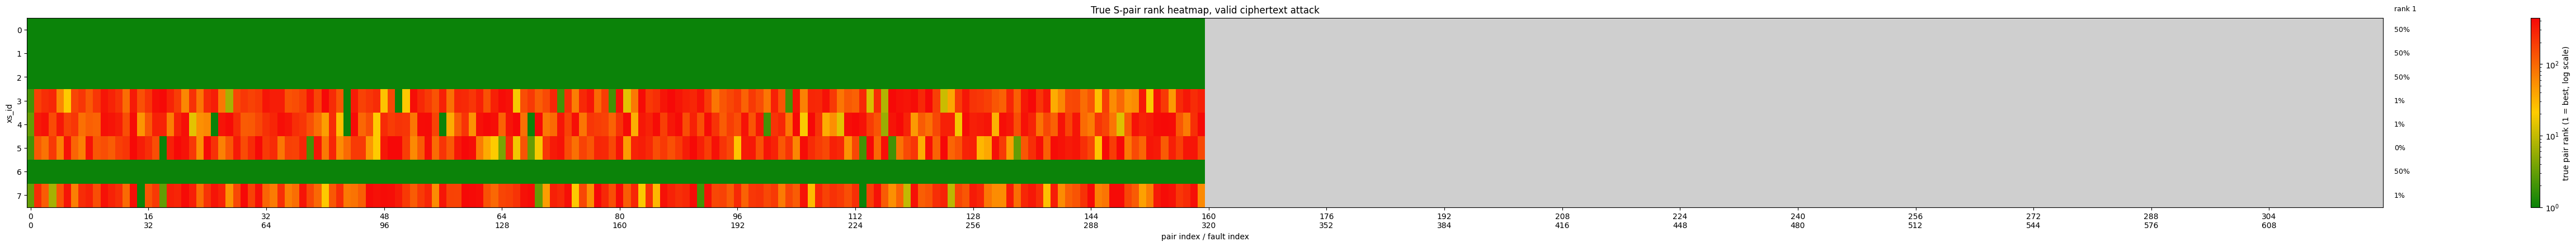

Saved rank heatmap to Results_decapsulation_truncated_differentS/heatmap_valid_ciphertext.png
Rank summary:
count    1280.000000
mean      104.544531
std       138.034243
min         1.000000
25%         1.000000
50%         1.000000
75%       200.250000
max       441.000000
dtype: float64


In [61]:
def rank_df_to_full_compact_S_pairs(rank_df, S_matrix):
    no_pairs_total = S_matrix.shape[0] // 2
    full_rank_df = pd.DataFrame(
        np.nan,
        index=rank_df.index,
        columns=[f"S_pair_{pair_idx}" for pair_idx in range(no_pairs_total)],
    )

    for column in rank_df.columns:
        pair_idx = int(str(column).replace("S_pair_", ""))
        if pair_idx < no_pairs_total:
            full_rank_df[f"S_pair_{pair_idx}"] = rank_df[column]

    return full_rank_df


rank_valid_full_df = rank_df_to_full_compact_S_pairs(rank_valid_df, S_real)

rank_valid_heatmap_path = plot_rank_heatmap(
    rank_valid_full_df,
    title="True S-pair rank heatmap, valid ciphertext attack",
    save_path=os.path.join(
        result_dir_truncated,
        "heatmap_valid_ciphertext.png",
    ),
)


## Combination between independednt and dependent guesses 

### Helpers

In [62]:
B_PREFIX = "B_from_registers_packed"
BASE_FAULT_INDEX = 0
COMBINED_FAULT_INDICES_FOR_PAIRS = FAULT_INDICES_FOR_PAIRS
TRASH_HOLD = 0.9998

DIFFERENT_S_OUTPUT_DIR = Path("output_decapsulation_truncated_different_S")
DIFFERENT_S_TRACE_DIR = DIFFERENT_S_OUTPUT_DIR
DIFFERENT_S_B_FOLDER = DIFFERENT_S_OUTPUT_DIR / "B"
DIFFERENT_S_S_FOLDER = DIFFERENT_S_OUTPUT_DIR / "S"
DIFFERENT_S_RESULT_DIR = Path("Results_truncated_different_S")
reset_folder(DIFFERENT_S_RESULT_DIR)

DIFFERENT_S_B_PREFIX = "B_from_registers_packed"
DIFFERENT_S_BASE_FAULT_INDEX = 0
DIFFERENT_S_FAULT_INDICES_FOR_PAIRS = [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20]
DIFFERENT_S_TRASH_HOLD = TRASH_HOLD

VALID_PER_S_OUTPUT_DIR = Path("output_truncated_different_ciphertext_per_S")
VALID_PER_S_TRACE_DIR = VALID_PER_S_OUTPUT_DIR
VALID_PER_S_B_FOLDER = VALID_PER_S_OUTPUT_DIR / "B"
VALID_PER_S_S_FOLDER = VALID_PER_S_OUTPUT_DIR / "S"
VALID_PER_S_RESULT_DIR = Path("Results_truncated_valid_per_S")
VALID_PER_S_B_PREFIX = "B_valid_from_registers_packed"
VALID_PER_S_FAULT_INDICES_FOR_PAIRS = list(range(0, 22, 2))
VALID_PER_S_TRASH_HOLD = 0.9998

os.makedirs(VALID_PER_S_RESULT_DIR, exist_ok=True)


Helpers for guessing the best pair from context

In [ ]:
def score_pair_guesses_from_context( B_values, b_row, pair_idx, traces_hw, hw_index, S_guesses, instructions_before=0, instructions_after=10, r0_old=None):
    traces_window, hw_local_index = trace_window_at_hw_index( traces_hw, hw_index, instructions_before=instructions_before, instructions_after=instructions_after)
    if r0_old is None:
        r0_old = np.zeros(B_values.shape[0], dtype=np.int32)

    return score_all_pair_guesses(B_values, b_row, pair_idx, r0_old, traces_window, hw_local_index, S_guesses)


#### Same-HW candidate helpers


In [65]:
def candidate_pair_product(B_values, b_row, pair_idx, candidate):
    B_i, B_j = packed_pair_values(B_values, b_row, pair_idx)
    return B_i * int(candidate["S0"]) + B_j * int(candidate["S1"])


def candidate_product_hw_signature(B_values, b_row, pair_idx, candidate):
    pair_product = candidate_pair_product(B_values, b_row, pair_idx, candidate)
    return tuple(hw_u32(pair_product & 0xffffffff).tolist())


def add_independent_hw_signatures(independent_scores, B_independent, b_row, pair_idx):
    for candidate in independent_scores:
        product_hw_signature = candidate_product_hw_signature(B_independent, b_row, pair_idx, candidate)
        candidate["product_hw_signature"] = product_hw_signature
        candidate["independent_hw_signature"] = product_hw_signature
    return independent_scores


#### Same-HW context scoring helpers


In [ ]:
def same_hw_signature(candidate):
    return candidate["product_hw_signature"]


def same_hw_candidates(independent_scores, selected_candidate, min_rank=1):
    signature = same_hw_signature(selected_candidate)
    return [
        {**candidate, "same_hw_independent_rank": rank}
        for rank, candidate in enumerate(independent_scores, start=1)
        if rank >= min_rank and same_hw_signature(candidate) == signature
    ]


def best_same_hw_candidate_in_context(selected_candidate, independent_scores, B_context, b_row, pair_idx, r0_old, context_window, context_hw_local_index, min_rank=1):
    checked = []
    for candidate in same_hw_candidates(independent_scores, selected_candidate, min_rank=min_rank):
        corr, pair_product = score_candidate(candidate, B_context, b_row, pair_idx, r0_old, context_window, context_hw_local_index)
        checked.append({**candidate, "base_corr": corr, "base_pair_product": pair_product})

    accepted = max(checked, key=lambda row: abs(row["base_corr"]))
    accepted["same_hw_candidates_checked"] = len(checked)
    return accepted


def same_hw_context_candidates(independent_scores, B_context, b_row, pair_idx, r0_old, context_window, context_hw_local_index, rank_offset=0, max_candidates_to_check=None):
    candidates = independent_scores[rank_offset:]
    if max_candidates_to_check is not None:
        candidates = candidates[:max_candidates_to_check]

    context_checked = []
    seen_hw_signatures = set()
    for local_rank, selected_candidate in enumerate(candidates, start=1):
        signature = same_hw_signature(selected_candidate)
        if signature in seen_hw_signatures:
            continue
        seen_hw_signatures.add(signature)

        accepted = best_same_hw_candidate_in_context(
            selected_candidate,
            independent_scores,
            B_context,
            b_row,
            pair_idx,
            r0_old,
            context_window,
            context_hw_local_index,
            min_rank=rank_offset + 1,
        )
        accepted["selected_independent_rank"] = rank_offset + local_rank
        accepted["modified_rank"] = accepted["same_hw_independent_rank"]
        context_checked.append(accepted)

    return context_checked


def best_same_hw_context_candidate(independent_scores, B_context, b_row, pair_idx, r0_old, context_window, context_hw_local_index, rank_offset=0, max_candidates_to_check=None):
    context_checked = same_hw_context_candidates(independent_scores, B_context, b_row, pair_idx, r0_old, context_window, context_hw_local_index, rank_offset=rank_offset, max_candidates_to_check=max_candidates_to_check)
    
    if not context_checked:
        return None
    return max(context_checked, key=lambda row: abs(row["base_corr"]))


#### Progressive chain helpers

Compute the candidate. If the candidate goes under the trashhold value, teh entire chain will be recalculated with another first pair. 

In [ ]:
def run_progressive_xs_chain(
    xs_id,
    fault_indices,
    base_fault_index,
    force_first_pair_rank,
    get_independent_scores,
    get_progressive_context,
    get_true_pair,
    build_detail,
    retry_score_threshold,
    max_candidates_to_check=None,
    force_first_pair_zero=False,
    rank_key="rank",
    corr_key="corr",
    product_key="pair_product",
    print_prefix="",
    rank_in_progressive_context=False,
):

    def accept_candidate(candidate, candidate_rank, B_progressive, b_row, pair_idx, r0_old, progressive_window, progressive_hw_local_index):
        if rank_in_progressive_context and corr_key in candidate and product_key in candidate:
            return candidate
        corr, pair_product = score_candidate(candidate, B_progressive, b_row, pair_idx, r0_old, progressive_window, progressive_hw_local_index)
        return {**candidate, rank_key: candidate_rank, corr_key: corr, product_key: pair_product}

    def zero_fallback(independent_scores, B_progressive, b_row, pair_idx, r0_old, progressive_window, progressive_hw_local_index):
        """In the case in which none of the candidates passes the trashhold value, then consider the pair (0,0) instead of none"""
        zero_rank, zero_candidate = find_candidate(independent_scores, 0, 0)
        accepted = accept_candidate(zero_candidate, zero_rank, B_progressive, b_row, pair_idx, r0_old, progressive_window, progressive_hw_local_index)
        accepted["used_zero_fallback"] = True
        return accepted

    def retry_result(pair_idx, retry_score):
        return {"details": details, "retry_triggered": True, "retry_pair_idx": pair_idx, "retry_score": retry_score}

    b_row = xs_id
    r0_old = None
    details = []

    for pair_idx, fault_index in enumerate(fault_indices):
        expected_fault_index = 2 * pair_idx
        if fault_index != expected_fault_index:
            raise ValueError(f"fault_index must isolate the current packed pair: pair_idx={pair_idx}, fault_index={fault_index}, expected={expected_fault_index}")

        b_col = fault_index
        independent_scores = get_independent_scores(xs_id, b_row, pair_idx, fault_index)
        B_progressive, progressive_window, progressive_hw_local_index = get_progressive_context(xs_id, b_row, pair_idx, fault_index)

        if r0_old is None:
            r0_old = np.zeros(B_progressive.shape[0], dtype=np.int32)

        if rank_in_progressive_context:
            progressive_scores = [
                accept_candidate(candidate, candidate_rank, B_progressive, b_row, pair_idx, r0_old, progressive_window, progressive_hw_local_index)
                for candidate_rank, candidate in enumerate(independent_scores, start=1)
            ]
            independent_scores = sorted(progressive_scores, key=lambda row: abs(row[corr_key]), reverse=True)

        if force_first_pair_zero and fault_index == base_fault_index:
            accepted = zero_fallback(independent_scores, B_progressive, b_row, pair_idx, r0_old, progressive_window, progressive_hw_local_index)
        elif force_first_pair_zero:
            accepted = accept_candidate(independent_scores[0], 1, B_progressive, b_row, pair_idx, r0_old, progressive_window, progressive_hw_local_index)
            accepted["used_independent_fallback"] = True
        elif fault_index == base_fault_index:
            forced_index = min(max(force_first_pair_rank - 1, 0), len(independent_scores) - 1)
            accepted = accept_candidate(independent_scores[forced_index], forced_index + 1, B_progressive, b_row, pair_idx, r0_old, progressive_window, progressive_hw_local_index)
        else:
            candidates = independent_scores if max_candidates_to_check is None else independent_scores[:max_candidates_to_check]
            checked_candidates = [
                accept_candidate(candidate, candidate_rank, B_progressive, b_row, pair_idx, r0_old, progressive_window, progressive_hw_local_index)
                for candidate_rank, candidate in enumerate(candidates, start=1)
            ]
            accepted = max(checked_candidates, key=lambda row: abs(row[corr_key])) if checked_candidates else None
            accepted_abs_corr = 0.0 if accepted is None else abs(accepted[corr_key])
            if accepted is None or accepted_abs_corr < retry_score_threshold:
                print(f"[EARLY STOP] {print_prefix}xs_id={xs_id}, pair={pair_idx}: best_corr={accepted_abs_corr:.4f} < {retry_score_threshold}. Restarting chain with another first-pair candidate.")
                return retry_result(pair_idx, accepted_abs_corr)

        accepted_abs_corr = abs(accepted[corr_key])
        if not force_first_pair_zero and fault_index == base_fault_index and accepted_abs_corr < retry_score_threshold:
            print(f"[EARLY STOP] {print_prefix}xs_id={xs_id}, pair={pair_idx}: first-pair corr={accepted_abs_corr:.4f} < {retry_score_threshold}. Restarting chain with another first-pair candidate.")
            return retry_result(pair_idx, accepted_abs_corr)

        S0_true, S1_true = get_true_pair(b_col, xs_id)
        true_rank = rank_of_true_pair(independent_scores, S0_true, S1_true)
        is_correct = (accepted["S0"], accepted["S1"]) == (S0_true, S1_true)
        r0_old = r0_old + accepted[product_key]

        detail = build_detail(xs_id, pair_idx, fault_index, b_col, accepted, S0_true, S1_true, true_rank, is_correct, force_first_pair_rank)
        if "combined" in print_prefix:
            detail.update(B_pair_detail_values(B_progressive, b_row, pair_idx))
        details.append(detail)

        print(f"{print_prefix}xs_id={xs_id}, pair={pair_idx}, fault={fault_index}, accepted=({accepted['S0']},{accepted['S1']}) rank={accepted[rank_key]} corr={accepted[corr_key]:.4f}, true=({S0_true},{S1_true}), true_rank={true_rank}")
        if not is_correct and "combined" in print_prefix:
            print(f"[WRONG PAIR B VALUES] {print_prefix}xs_id={xs_id}, pair={pair_idx}, fault={fault_index}, {format_B_pair_values(B_progressive, b_row, pair_idx)}")

    return {"details": details, "retry_triggered": False, "retry_pair_idx": None, "retry_score": None}


def run_progressive_chain_with_retries(
    xs_id,
    fault_indices,
    base_fault_index,
    get_independent_scores,
    get_progressive_context,
    get_true_pair,
    build_detail,
    retry_score_threshold,
    max_first_pair_rank,
    max_candidates_to_check=None,
    fallback_to_zero=False,
    rank_key="rank",
    corr_key="corr",
    product_key="pair_product",
    print_prefix="",
    context="",
    rank_in_progressive_context=False,
):
    first_pair_rank = 1

    while True:
        result = run_progressive_xs_chain(
            xs_id,
            fault_indices,
            base_fault_index,
            first_pair_rank,
            get_independent_scores,
            get_progressive_context,
            get_true_pair,
            build_detail,
            retry_score_threshold,
            max_candidates_to_check=max_candidates_to_check,
            force_first_pair_zero=False,
            rank_key=rank_key,
            corr_key=corr_key,
            product_key=product_key,
            print_prefix=print_prefix,
            rank_in_progressive_context=rank_in_progressive_context,
        )
        if not result["retry_triggered"]:
            return result

        first_pair_rank += 1
        if first_pair_rank <= max_first_pair_rank:
            print(f"[RETRY] {context}: abs(corr)={result['retry_score']:.4f} at pair={result['retry_pair_idx']} < {retry_score_threshold}. Retrying with pair 0 forced to candidate rank {first_pair_rank}.")
            continue

        if fallback_to_zero:
            print(f"[RETRY STOP] {context}: no candidate reached the threshold after rank {first_pair_rank - 1}. Falling back to pair (0,0).")
            return run_progressive_xs_chain(
                xs_id,
                fault_indices,
                base_fault_index,
                1,
                get_independent_scores,
                get_progressive_context,
                get_true_pair,
                build_detail,
                retry_score_threshold,
                max_candidates_to_check=max_candidates_to_check,
                force_first_pair_zero=True,
                rank_key=rank_key,
                corr_key=corr_key,
                product_key=product_key,
                print_prefix=print_prefix,
                rank_in_progressive_context=rank_in_progressive_context,
            )

        print(f"[RETRY STOP] {context}: no more first-pair candidates after rank {first_pair_rank - 1}. Keeping the last result.")
        return result


def run_same_hw_xs_chain(xs_id, fault_indices, base_fault_index, B_base, base_traces_hw, selected_runs, independent_scores_by_pair, first_pair_rank=1, threshold=TRASH_HOLD, instructions_before=0, instructions_after=10, max_candidates_to_check=None):
    b_row = xs_id
    r0_old = np.zeros(len(selected_runs), dtype=np.int32)
    details = []

    for pair_idx, fault_index in enumerate(fault_indices):
        expected_fault_index = 2 * pair_idx
        if fault_index != expected_fault_index:
            raise ValueError(f"fault_index must isolate the current packed pair: pair_idx={pair_idx}, fault_index={fault_index}, expected={expected_fault_index}")

        b_col = fault_index
        independent_scores = independent_scores_by_pair[pair_idx]
        B_context, context_window, context_hw_local_index = same_hw_base_context(B_base, base_traces_hw, selected_runs, xs_id, b_row, pair_idx, base_fault_index, instructions_before=instructions_before, instructions_after=instructions_after)
        rank_offset = min(max(first_pair_rank - 1, 0), len(independent_scores) - 1) if fault_index == base_fault_index else 0
        accepted = best_same_hw_context_candidate(independent_scores, B_context, b_row, pair_idx, r0_old, context_window, context_hw_local_index, rank_offset=rank_offset, max_candidates_to_check=max_candidates_to_check)

        accepted_abs_corr = 0.0 if accepted is None else abs(accepted["base_corr"])
        if accepted is None or (fault_index != base_fault_index and accepted_abs_corr < threshold):
            if accepted is not None:
                print(f"[REJECTED] xs_id={xs_id}, pair={pair_idx}, fault={fault_index}, candidate=({accepted['S0']},{accepted['S1']}) rank={accepted['modified_rank']} corr={accepted['base_corr']:.4f} < {threshold}")
            print(f"[RESTART] xs_id={xs_id}, pair={pair_idx}, fault={fault_index}: best corr={accepted_abs_corr:.4f} < {threshold}; retrying with another first-pair candidate")
            return {"details": details, "retry_triggered": True, "retry_pair_idx": pair_idx, "retry_score": accepted_abs_corr, "rejected_candidate": accepted}

        if fault_index == base_fault_index and accepted_abs_corr < threshold:
            print(f"[PAIR 0 BELOW THRESHOLD] xs_id={xs_id}, pair={pair_idx}, fault={fault_index}: best corr={accepted_abs_corr:.4f} < {threshold}; accepting best context candidate anyway")

        r0_old = r0_old + accepted["base_pair_product"]
        S0_true = int(S_real[b_col, xs_id])
        S1_true = int(S_real[b_col + 1, xs_id])
        true_rank = rank_of_true_pair(independent_scores, S0_true, S1_true)
        is_correct = (accepted["S0"], accepted["S1"]) == (S0_true, S1_true)
        details.append(same_hw_detail_row(xs_id, pair_idx, fault_index, first_pair_rank, accepted, S0_true, S1_true, is_correct, B_context, b_row))

        print(f"xs_id={xs_id}, pair={pair_idx}, fault={fault_index}, accepted=({accepted['S0']},{accepted['S1']}) rank={accepted['modified_rank']} corr={accepted['base_corr']:.4f}, true=({S0_true},{S1_true}), true_rank={true_rank}")

    return {"details": details, "retry_triggered": False, "retry_pair_idx": None, "retry_score": None, "rejected_candidate": None}


### Modified CPA for one S 

#### Single-S grid setup


In [72]:
SINGLE_S_TRACE_COUNTS = [5, 10, 20]
SINGLE_S_FAULT_LIMITS = [20, 60, 120, 240, 320]
SINGLE_S_THRESHOLD = 0.998
SINGLE_S_COMPARISON_JOBS = 10
SINGLE_S_GRID_RESULT_DIR = Path(result_dir_truncated) / "single_S_grid_comparison"
SINGLE_S_GRID_RESULT_DIR.mkdir(parents=True, exist_ok=True)


def fault_indices_for_limit(fault_limit):
    return list(range(0, int(fault_limit), 2))


def pair_indices_for_fault_limit(fault_limit):
    return list(range(len(fault_indices_for_limit(fault_limit))))


def success_rate_from_details(details_df):
    if details_df.empty:
        return np.nan
    return float(details_df["is_correct"].mean())


def candidate_guess_space(S_guesses=S_GUESSES):
    return [
        {"S0": int(S0_guess), "S1": int(S1_guess)}
        for S0_guess in S_guesses
        for S1_guess in S_guesses
    ]


#### Valid progressive retry attack


In [ ]:
def valid_progressive_retry_attack(
    xs_ids=range(8),
    fault_indices=COMBINED_FAULT_INDICES_FOR_PAIRS,
    S_guesses=S_GUESSES,
    threshold=SINGLE_S_THRESHOLD,
    instructions_before=0,
    instructions_after=10,
    max_runs=None,
):
    fault_indices = list(fault_indices)
    pair_count = len(fault_indices)
    B_valid_packed, valid_runs = load_all_B(B_folder, prefix=VALID_B_PREFIX)

    if max_runs is not None:
        valid_runs = valid_runs[:max_runs]
        B_valid_packed = B_valid_packed[:len(valid_runs)]

    guess_space = candidate_guess_space(S_guesses)
    all_details = []

    for xs_id in xs_ids:
        b_row = xs_id
        valid_traces_hw = load_hw_r0_for_fault(xs_id, None, valid_runs, mode="valid")
        first_pair_rank = 1

        while True:
            r0_old = np.zeros(len(valid_runs), dtype=np.int32)
            xs_details = []
            retry_triggered = False
            retry_pair_idx = None
            retry_score = None

            for pair_idx, fault_index in enumerate(fault_indices):
                b_col = fault_index
                hw_index = smlad_hw_index(xs_id=xs_id, b_row=b_row, pair_idx=pair_idx, fault_index=None, reference_run=valid_runs[0], mode="valid")
                traces_window, hw_local_index = trace_window_at_hw_index(valid_traces_hw, hw_index, instructions_before=instructions_before, instructions_after=instructions_after)

                ranked_candidates = []
                for candidate_rank, candidate in enumerate(guess_space, start=1):
                    corr, pair_product = score_candidate(candidate, B_valid_packed, b_row, pair_idx, r0_old, traces_window, hw_local_index)
                    ranked_candidates.append({**candidate, "valid_rank": candidate_rank, "valid_corr": corr, "valid_pair_product": pair_product})
                ranked_candidates.sort(key=lambda row: abs(row["valid_corr"]), reverse=True)

                if pair_idx == 0:
                    accepted = ranked_candidates[min(first_pair_rank - 1, len(ranked_candidates) - 1)]
                else:
                    accepted = ranked_candidates[0]

                accepted_corr = abs(accepted["valid_corr"])
                if accepted_corr < threshold:
                    retry_triggered = True
                    retry_pair_idx = pair_idx
                    retry_score = accepted_corr
                    print(f"[RETRY] valid xs_id={xs_id}, pair={pair_idx}: corr={accepted_corr:.4f} < {threshold}; changing first pair")
                    break

                S0_true = int(S_real[b_col, xs_id])
                S1_true = int(S_real[b_col + 1, xs_id])
                true_rank = rank_of_true_pair(ranked_candidates, S0_true, S1_true)
                is_correct = (accepted["S0"], accepted["S1"]) == (S0_true, S1_true)
                r0_old = r0_old + accepted["valid_pair_product"]

                xs_details.append({
                    "xs_id": xs_id,
                    "pair_idx": pair_idx,
                    "S_true": f"({S0_true},{S1_true})",
                    "S_guessed": f"({accepted['S0']},{accepted['S1']})",
                    "S_rank": true_rank,
                    "correlation_score": accepted["valid_corr"],
                    "is_correct": is_correct,
                })
                print(f"valid xs_id={xs_id}, pair={pair_idx}, accepted=({accepted['S0']},{accepted['S1']}) rank={true_rank} corr={accepted['valid_corr']:.4f}, true=({S0_true},{S1_true})")

            if not retry_triggered:
                all_details.extend(xs_details)
                break

            first_pair_rank += 1
            if first_pair_rank <= len(guess_space):
                print(f"[RETRY] valid xs_id={xs_id}: corr={retry_score:.4f} at pair={retry_pair_idx}; restarting with first-pair rank {first_pair_rank}")
                continue

            print(f"[RETRY STOP] valid xs_id={xs_id}: no first-pair candidate reached {threshold}; using pair (0,0) and best remaining candidates")
            r0_old = np.zeros(len(valid_runs), dtype=np.int32)
            xs_details = []
            for pair_idx, fault_index in enumerate(fault_indices):
                b_col = fault_index
                hw_index = smlad_hw_index(xs_id=xs_id, b_row=b_row, pair_idx=pair_idx, fault_index=None, reference_run=valid_runs[0], mode="valid")
                traces_window, hw_local_index = trace_window_at_hw_index(valid_traces_hw, hw_index, instructions_before=instructions_before, instructions_after=instructions_after)
                ranked_candidates = []
                for candidate_rank, candidate in enumerate(guess_space, start=1):
                    corr, pair_product = score_candidate(candidate, B_valid_packed, b_row, pair_idx, r0_old, traces_window, hw_local_index)
                    ranked_candidates.append({**candidate, "valid_rank": candidate_rank, "valid_corr": corr, "valid_pair_product": pair_product})
                ranked_candidates.sort(key=lambda row: abs(row["valid_corr"]), reverse=True)
                accepted = find_candidate(ranked_candidates, 0, 0)[1] if pair_idx == 0 else ranked_candidates[0]
                if pair_idx == 0 and accepted.get("valid_pair_product") is None:
                    accepted["valid_corr"], accepted["valid_pair_product"] = score_candidate(accepted, B_valid_packed, b_row, pair_idx, r0_old, traces_window, hw_local_index)
                S0_true = int(S_real[b_col, xs_id])
                S1_true = int(S_real[b_col + 1, xs_id])
                true_rank = rank_of_true_pair(ranked_candidates, S0_true, S1_true)
                is_correct = (accepted["S0"], accepted["S1"]) == (S0_true, S1_true)
                r0_old = r0_old + accepted["valid_pair_product"]
                xs_details.append({"xs_id": xs_id, "pair_idx": pair_idx, "S_true": f"({S0_true},{S1_true})", "S_guessed": f"({accepted['S0']},{accepted['S1']})", "S_rank": true_rank, "correlation_score": accepted["valid_corr"], "is_correct": is_correct})
            all_details.extend(xs_details)
            break

    details_df = pd.DataFrame(all_details)
    os.makedirs(result_dir_truncated, exist_ok=True)
    details_path = os.path.join(result_dir_truncated, "S_pair_valid_progressive_retry_details.csv")
    details_df.to_csv(details_path, index=False)
    print(f"Valid retry success rate with {len(valid_runs)} traces and {pair_count} pairs: {details_df['is_correct'].mean():.2%}")
    print(f"Saved details to {details_path}")
    return details_df


def valid_progressive_retry_attack_for_grid(trace_count, fault_limit, threshold=SINGLE_S_THRESHOLD):
    details_df = valid_progressive_retry_attack(fault_indices=fault_indices_for_limit(fault_limit), max_runs=trace_count, threshold=threshold).copy()
    details_df.insert(0, "attack", "valid_retry")
    details_df["trace_count"] = trace_count
    details_df["fault_limit"] = fault_limit
    details_df["pair_count"] = len(fault_indices_for_limit(fault_limit))
    return details_df


#### Run valid progressive retry attack


In [ ]:
details_valid_retry_df = valid_progressive_retry_attack(max_runs=None, threshold=TRASH_HOLD)

rank_valid_retry_df = (
    details_valid_retry_df
    .pivot(index="xs_id", columns="pair_idx", values="S_rank")
    .sort_index()
)
rank_valid_retry_df.columns = [f"S_pair_{int(pair_idx)}" for pair_idx in rank_valid_retry_df.columns]
rank_valid_retry_full_df = rank_df_to_full_compact_S_pairs(rank_valid_retry_df, S_real)

rank_valid_retry_heatmap_path = plot_rank_heatmap(
    rank_valid_retry_full_df,
    title="True S-pair rank heatmap, valid progressive retry attack",
    save_path=os.path.join(result_dir_truncated, "heatmap_valid_progressive_retry.png"),
)


#### Run the attack with trashold check and first pair modification (NO similar HW)

In [ ]:
def combined_modified_base_attack(
    xs_ids=range(8),
    fault_indices=COMBINED_FAULT_INDICES_FOR_PAIRS,
    base_fault_index=BASE_FAULT_INDEX,
    S_guesses=S_GUESSES,
    instructions_before=0,
    instructions_after=10,
    max_runs=None,
    max_candidates_to_check=None,
    retry_base_score_threshold=TRASH_HOLD,
):
    """Rank pairs on isolated modified traces, then verify them on the base accumulator trace."""
    B_by_fault, selected_runs = load_combined_modified_base_inputs(
        B_folder,
        B_PREFIX,
        fault_indices,
        base_fault_index=base_fault_index,
        max_runs=max_runs,
    )
    B_base = B_by_fault[base_fault_index]
    base_traces_by_xs = {
        xs_id: load_hw_r0_for_fault(xs_id, base_fault_index, selected_runs, mode="modified")
        for xs_id in xs_ids
    }
    all_details = []

    def modified_hw_index(xs_id, b_row, pair_idx, fault_index):
        return smlad_hw_index(
            xs_id=xs_id,
            b_row=b_row,
            pair_idx=pair_idx,
            fault_index=fault_index,
            reference_run=selected_runs[0],
            mode="modified",
        )

    def get_base_context(xs_id, b_row, pair_idx, fault_index):
        hw_index = modified_hw_index(xs_id, b_row, pair_idx, base_fault_index)
        traces_window, hw_local_index = trace_window_at_hw_index(base_traces_by_xs[xs_id], hw_index, instructions_before=instructions_before, instructions_after=instructions_after)
        return B_base, traces_window, hw_local_index

    def get_independent_scores(current_xs, b_row, pair_idx, fault_index):
        B_independent = B_by_fault[fault_index]
        assert_previous_packed_pairs_zero(
            B_independent,
            b_row,
            pair_idx,
            fault_index=fault_index,
            label=f"combined independent xs_id={current_xs} pair={pair_idx}",
        )
        return score_pair_guesses_from_context(
            B_independent,
            b_row,
            pair_idx,
            load_hw_r0_for_fault(current_xs, fault_index, selected_runs, mode="modified"),
            modified_hw_index(current_xs, b_row, pair_idx, fault_index),
            S_guesses,
            instructions_before=instructions_before,
            instructions_after=instructions_after,
        )

    def get_true_pair(b_col, xs_id):
        return int(S_real[b_col, xs_id]), int(S_real[b_col + 1, xs_id])

    def build_detail(xs_id, pair_idx, fault_index, b_col, accepted, S0_true, S1_true, true_rank, is_correct, force_first_pair_rank):
        return {
            "xs_id": xs_id,
            "pair_idx": pair_idx,
            "fault_index": fault_index,
            "S_true": f"({S0_true},{S1_true})",
            "S_guessed": f"({accepted['S0']},{accepted['S1']})",
            "S_rank": accepted["modified_rank"],
            "correlation_score": accepted["base_corr"],
            "is_correct": is_correct,
        }

    for xs_id in xs_ids:
        print(f"xs_id={xs_id}")
        result = run_progressive_chain_with_retries(
            xs_id=xs_id,
            fault_indices=fault_indices,
            base_fault_index=base_fault_index,
            get_independent_scores=get_independent_scores,
            get_progressive_context=get_base_context,
            get_true_pair=get_true_pair,
            build_detail=build_detail,
            retry_score_threshold=retry_base_score_threshold,
            max_first_pair_rank=len(S_guesses) ** 2,
            max_candidates_to_check=max_candidates_to_check,
            fallback_to_zero=True,
            rank_key="modified_rank",
            corr_key="base_corr",
            product_key="base_pair_product",
            print_prefix="combined with context check",
            context=f"xs_id={xs_id}",
        )
        all_details.extend(result["details"])

    details_df = pd.DataFrame(all_details)
    os.makedirs(result_dir_truncated, exist_ok=True)
    details_df.to_csv(os.path.join(result_dir_truncated, "S_pair_combined_modified_base_details.csv"), index=False)

    success_rate = details_df.groupby("xs_id").tail(len(fault_indices))["is_correct"].mean()
    print(f"Success rate with {len(selected_runs)} traces: {success_rate:.2%}")

    return details_df


details_combined_df = combined_modified_base_attack(max_runs=None, max_candidates_to_check=None, retry_base_score_threshold=TRASH_HOLD)


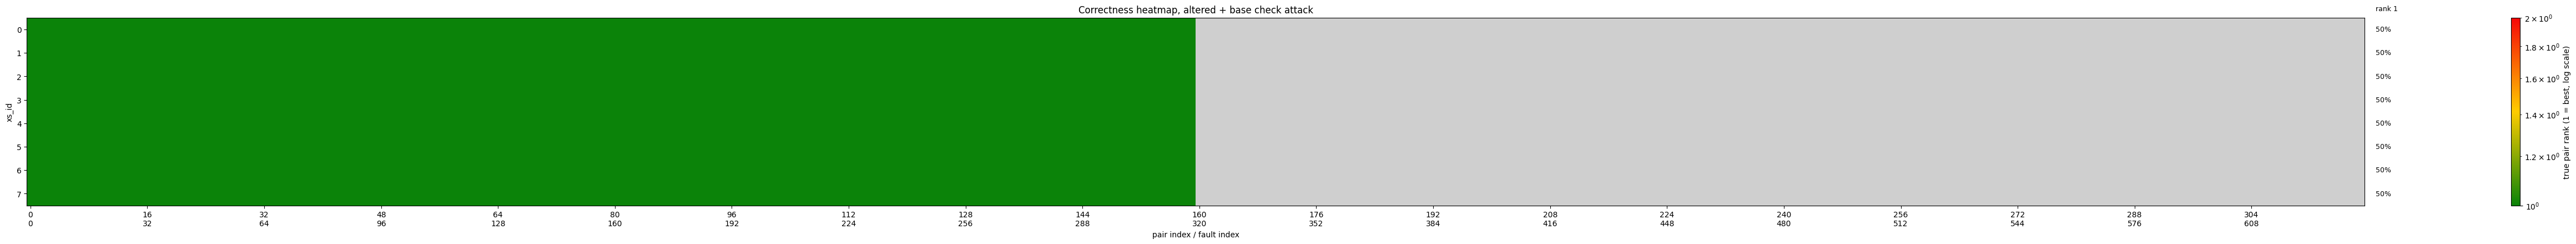

Saved rank heatmap to Results_decapsulation_truncated_differentS/heatmap_rank_combine.png
Rank summary:
count    1280.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
dtype: float64


In [71]:
rank_combined_df = (
    details_combined_df
    .assign(correct_rank=lambda df: np.where(df["is_correct"], 1, 2))
    .pivot(index="xs_id", columns="pair_idx", values="correct_rank")
    .sort_index()
)
rank_combined_df.columns = [f"S_pair_{int(pair_idx)}" for pair_idx in rank_combined_df.columns]
rank_combined_full_df = rank_df_to_full_compact_S_pairs(rank_combined_df, S_real)

rank_combined_heatmap_path = plot_rank_heatmap(
    rank_combined_full_df,
    title="Correctness heatmap, altered + base check attack",
    save_path=os.path.join(
        result_dir_truncated,
        "heatmap_rank_combine.png",
    ),
)


#### CPA same-HW candidate + accumulator context check


In [67]:
def hw_signed_i16(value):
    return int((int(value) & 0xffff).bit_count())


S_guess_hw_rows = []
for S0_guess in S_GUESSES:
    for S1_guess in S_GUESSES:
        hw_pair = hw_signed_i16(S0_guess) + hw_signed_i16(S1_guess)
        S_guess_hw_rows.append({
            "HW": hw_pair,
            "S_pair": f"({int(S0_guess)},{int(S1_guess)})",
        })

S_guess_hw_df = (
    pd.DataFrame(S_guess_hw_rows)
    .groupby("HW", as_index=False)
    .agg(S_pairs=("S_pair", lambda values: " ".join(values)))
)

os.makedirs(result_dir_truncated, exist_ok=True)
S_guess_hw_path = os.path.join(result_dir_truncated, "S_guess_pairs_by_HW.csv")
S_guess_hw_df.to_csv(S_guess_hw_path, index=False)

print("Candidate S pairs grouped by total HW(S0) + HW(S1):")
display(S_guess_hw_df)
print(f"Saved HW pair groups to {S_guess_hw_path}")


Candidate S pairs grouped by total HW(S0) + HW(S1):


,HW,S_pairs
0,0,"(0,0)"
1,1,"(0,1) (0,2) (0,4) (0,8) (1,0) (2,0) (4,0) (8,0)"
2,2,"(0,3) (0,5) (0,6) (0,9) (0,10) (1,1) (1,2) (1,..."
3,3,"(0,7) (1,3) (1,5) (1,6) (1,9) (1,10) (2,3) (2,..."
4,4,"(1,7) (2,7) (3,3) (3,5) (3,6) (3,9) (3,10) (4,..."
5,5,"(3,7) (5,7) (6,7) (7,3) (7,5) (7,6) (7,9) (7,1..."
6,6,"(7,7)"
7,13,"(-8,0) (0,-8)"
8,14,"(-10,0) (-8,1) (-8,2) (-8,4) (-8,8) (-7,0) (-6..."
9,15,"(-10,1) (-10,2) (-10,4) (-10,8) (-9,0) (-8,3) ..."


Saved HW pair groups to Results_decapsulation_truncated_differentS/S_guess_pairs_by_HW.csv


### Choose the candidates with the same HW score 

In [ ]:
def same_hw_independent_scores_for_pair(B_by_fault, selected_runs, xs_id, b_row, pair_idx, fault_index, S_guesses, instructions_before=0, instructions_after=10):
    B_independent = B_by_fault[fault_index]
    assert_previous_packed_pairs_zero(
        B_independent,
        b_row,
        pair_idx,
        fault_index=fault_index,
        label=f"same-HW independent xs_id={xs_id} pair={pair_idx}",
    )
    hw_index = smlad_hw_index(xs_id=xs_id, b_row=b_row, pair_idx=pair_idx, fault_index=fault_index, reference_run=selected_runs[0], mode="modified")
    traces_hw = load_hw_r0_for_fault(xs_id, fault_index, selected_runs, mode="modified")
    scores = score_pair_guesses_from_context(B_independent, b_row, pair_idx, traces_hw, hw_index, S_guesses, instructions_before=instructions_before, instructions_after=instructions_after)
    return add_independent_hw_signatures(scores, B_independent, b_row, pair_idx)


def same_hw_base_context(B_base, base_traces_hw, selected_runs, xs_id, b_row, pair_idx, base_fault_index, instructions_before=0, instructions_after=10):
    hw_index = smlad_hw_index(xs_id=xs_id, b_row=b_row, pair_idx=pair_idx, fault_index=base_fault_index, reference_run=selected_runs[0], mode="modified")
    traces_window, hw_local_index = trace_window_at_hw_index(base_traces_hw, hw_index, instructions_before=instructions_before, instructions_after=instructions_after)
    return B_base, traces_window, hw_local_index


def same_hw_detail_row(xs_id, pair_idx, fault_index, first_pair_rank, accepted, S0_true, S1_true, is_correct, B_context, b_row):
    return {
        "xs_id": xs_id,
        "pair_idx": pair_idx,
        "fault_index": fault_index,
        "first_pair_rank": first_pair_rank,
        "S_true": f"({S0_true},{S1_true})",
        "S_guessed": f"({accepted['S0']},{accepted['S1']})",
        "S_rank": accepted["modified_rank"],
        "correlation_score": accepted["base_corr"],
        "is_correct": is_correct,
        **B_pair_detail_values(B_context, b_row, pair_idx),
    }


def same_hw_failed_rows(xs_id, fault_indices, first_pair_rank, completed_pairs, rejected_pair_idx, rejected, retry_score):
    rows = []
    for pair_idx, fault_index in enumerate(fault_indices):
        if pair_idx in completed_pairs:
            continue

        b_col = fault_index
        S0_true = int(S_real[b_col, xs_id])
        S1_true = int(S_real[b_col + 1, xs_id])
        row = {
            "xs_id": xs_id,
            "pair_idx": pair_idx,
            "fault_index": fault_index,
            "first_pair_rank": first_pair_rank,
            "S_true": f"({S0_true},{S1_true})",
            "S_guessed": "not_accepted",
            "S_rank": np.nan,
            "correlation_score": retry_score if pair_idx == rejected_pair_idx else np.nan,
            "is_correct": False,
            "chain_failed": True,
        }
        if rejected is not None and pair_idx == rejected_pair_idx:
            row["S_guessed"] = f"({rejected['S0']},{rejected['S1']})"
            row["S_rank"] = rejected.get("modified_rank", np.nan)
        rows.append(row)
    return rows


### Run the attack for the same HW with context check 

In [ ]:
def combined_modified_base_same_hw_attack(xs_ids=range(8), fault_indices=COMBINED_FAULT_INDICES_FOR_PAIRS, base_fault_index=BASE_FAULT_INDEX, S_guesses=S_GUESSES, instructions_before=0, instructions_after=10, max_runs=None, max_candidates_to_check=None, threshold=TRASH_HOLD):
    """Rank independently, expand same-HW candidates, and choose by accumulator-context correlation."""
    xs_ids = list(xs_ids)
    fault_indices = list(fault_indices)
    B_by_fault, selected_runs = load_combined_modified_base_inputs(B_folder, B_PREFIX, fault_indices, base_fault_index=base_fault_index, max_runs=max_runs)
    B_base = B_by_fault[base_fault_index]
    base_traces_by_xs = {xs_id: load_hw_r0_for_fault(xs_id, base_fault_index, selected_runs, mode="modified") for xs_id in xs_ids}
    max_first_pair_rank = len(S_guesses) ** 2
    all_details = []

    for xs_id in xs_ids:
        b_row = xs_id
        print(f"xs_id={xs_id}")
        independent_scores_by_pair = {
            pair_idx: same_hw_independent_scores_for_pair(B_by_fault, selected_runs, xs_id, b_row, pair_idx, fault_index, S_guesses, instructions_before=instructions_before, instructions_after=instructions_after)
            for pair_idx, fault_index in enumerate(fault_indices)
        }

        first_pair_rank = 1
        result = run_same_hw_xs_chain(xs_id, fault_indices, base_fault_index, B_base, base_traces_by_xs[xs_id], selected_runs, independent_scores_by_pair, first_pair_rank=first_pair_rank, threshold=threshold, instructions_before=instructions_before, instructions_after=instructions_after, max_candidates_to_check=max_candidates_to_check)
        while result["retry_triggered"] and first_pair_rank < max_first_pair_rank:
            first_pair_rank += 1
            print(f"[RETRY] xs_id={xs_id}: corr={result['retry_score']:.4f} at pair={result['retry_pair_idx']} < {threshold}; restarting chain with first-pair search from rank {first_pair_rank}")
            result = run_same_hw_xs_chain(xs_id, fault_indices, base_fault_index, B_base, base_traces_by_xs[xs_id], selected_runs, independent_scores_by_pair, first_pair_rank=first_pair_rank, threshold=threshold, instructions_before=instructions_before, instructions_after=instructions_after, max_candidates_to_check=max_candidates_to_check)

        if result["retry_triggered"]:
            completed_pairs = {row["pair_idx"] for row in result["details"]}
            print(f"[RETRY STOP] xs_id={xs_id}: all first-pair candidates were tried. Marking pair {result['retry_pair_idx']} and the remaining pairs as failed.")
            result["details"].extend(same_hw_failed_rows(xs_id, fault_indices, first_pair_rank, completed_pairs, result["retry_pair_idx"], result.get("rejected_candidate"), result["retry_score"]))
        else:
            for row in result["details"]:
                row["chain_failed"] = False

        all_details.extend(result["details"])

    details_df = pd.DataFrame(all_details)
    os.makedirs(result_dir_truncated, exist_ok=True)
    details_path = os.path.join(result_dir_truncated, "S_pair_combined_same_hw_modified_base_details.csv")
    details_df.to_csv(details_path, index=False)
    expected_rows = len(xs_ids) * len(fault_indices)
    success_rate = details_df["is_correct"].sum() / expected_rows if expected_rows else np.nan
    failed_xs = sorted(details_df.loc[details_df.get("chain_failed", False) == True, "xs_id"].unique()) if not details_df.empty else []
    print(f"Same-HW success rate with {len(selected_runs)} traces: {success_rate:.2%} ({details_df['is_correct'].sum()}/{expected_rows})")
    if failed_xs:
        print(f"Failed xs_id chains counted as failures: {failed_xs}")
    print(f"Saved details to {details_path}")
    return details_df


details_combined_same_hw_df = combined_modified_base_same_hw_attack(max_runs=None, max_candidates_to_check=None, threshold=TRASH_HOLD)


xs_id=0
xs_id=0, pair=0, fault=0, accepted=(3,-3) rank=1 corr=1.0000, true=(3,-3), true_rank=1
xs_id=0, pair=1, fault=2, accepted=(0,1) rank=1 corr=1.0000, true=(0,1), true_rank=1
xs_id=0, pair=2, fault=4, accepted=(-5,-3) rank=2 corr=1.0000, true=(-5,-3), true_rank=2
xs_id=0, pair=3, fault=6, accepted=(-3,-1) rank=2 corr=1.0000, true=(-3,-1), true_rank=2
xs_id=0, pair=4, fault=8, accepted=(3,2) rank=1 corr=1.0000, true=(3,2), true_rank=1
xs_id=0, pair=5, fault=10, accepted=(0,0) rank=221 corr=1.0000, true=(0,0), true_rank=221
xs_id=0, pair=6, fault=12, accepted=(-2,2) rank=1 corr=1.0000, true=(-2,2), true_rank=1
xs_id=0, pair=7, fault=14, accepted=(-3,3) rank=1 corr=1.0000, true=(-3,3), true_rank=1
xs_id=0, pair=8, fault=16, accepted=(-6,-1) rank=1 corr=1.0000, true=(-6,-1), true_rank=1
xs_id=0, pair=9, fault=18, accepted=(-3,4) rank=1 corr=1.0000, true=(-3,4), true_rank=1
xs_id=0, pair=10, fault=20, accepted=(-4,5) rank=1 corr=1.0000, true=(-4,5), true_rank=1
xs_id=0, pair=11, fault=

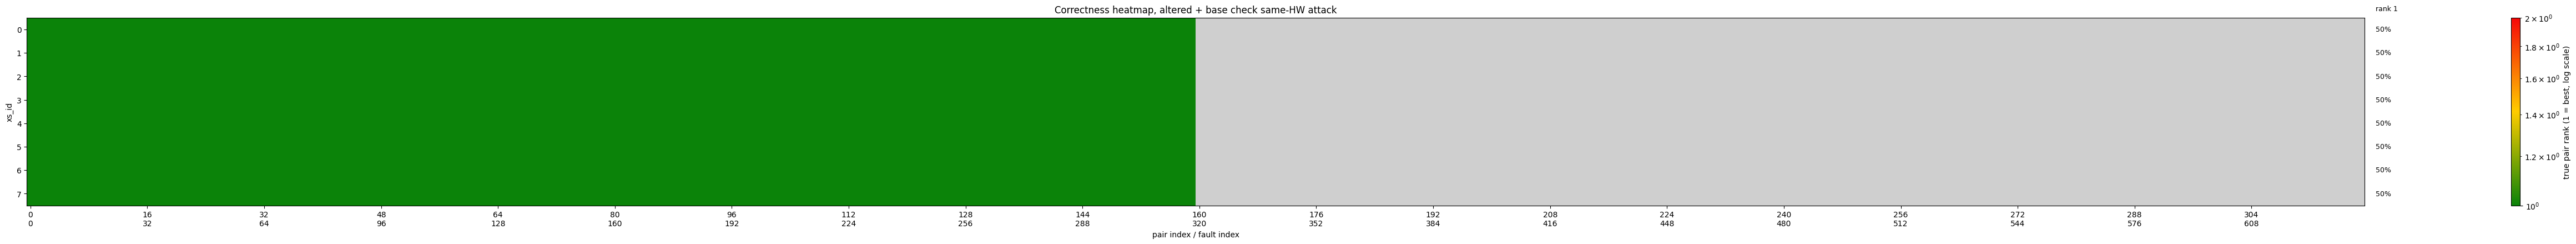

Saved rank heatmap to Results_decapsulation_truncated_differentS/heatmap_rank_combine_same_hw.png
Rank summary:
count    1280.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
dtype: float64


In [69]:
rank_combined_same_hw_df = (
    details_combined_same_hw_df
    .assign(correct_rank=lambda df: np.where(df["is_correct"], 1, 2))
    .pivot(index="xs_id", columns="pair_idx", values="correct_rank")
    .sort_index()
)
rank_combined_same_hw_df.columns = [f"S_pair_{int(pair_idx)}" for pair_idx in rank_combined_same_hw_df.columns]
rank_combined_same_hw_full_df = rank_df_to_full_compact_S_pairs(rank_combined_same_hw_df, S_real)

rank_combined_same_hw_heatmap_path = plot_rank_heatmap(
    rank_combined_same_hw_full_df,
    title="Correctness heatmap, altered + base check same-HW attack",
    save_path=os.path.join(
        result_dir_truncated,
        "heatmap_rank_combine_same_hw.png",
    ),
)


### Single-S comparison

Compare three attacks on the same S matrix with different numbers of traces and guessed pairs:
- valid ciphertext progressive accumulator attack with first-pair retry;
- altered ciphertext same-HW + base-context retry attack;
- altered ciphertext base-context retry attack without same-HW expansion.


In [74]:
def altered_same_hw_retry_attack_for_grid(trace_count, fault_limit, threshold=SINGLE_S_THRESHOLD):
    details_df = combined_modified_base_same_hw_attack(
        fault_indices=fault_indices_for_limit(fault_limit),
        max_runs=trace_count,
        max_candidates_to_check=None,
        threshold=threshold,
    ).copy()
    details_df.insert(0, "attack", "altered_same_hw_retry")
    details_df["trace_count"] = trace_count
    details_df["fault_limit"] = fault_limit
    details_df["pair_count"] = len(fault_indices_for_limit(fault_limit))
    return details_df


def altered_no_hw_retry_attack_for_grid(trace_count, fault_limit, threshold=SINGLE_S_THRESHOLD):
    details_df = combined_modified_base_attack(
        fault_indices=fault_indices_for_limit(fault_limit),
        max_runs=trace_count,
        max_candidates_to_check=None,
        retry_base_score_threshold=threshold,
    ).copy()
    details_df.insert(0, "attack", "altered_no_hw_retry")
    details_df["trace_count"] = trace_count
    details_df["fault_limit"] = fault_limit
    details_df["pair_count"] = len(fault_indices_for_limit(fault_limit))
    return details_df


def single_S_grid_job(job):
    attack = job["attack"]
    trace_count = job["trace_count"]
    fault_limit = job["fault_limit"]
    threshold = job["threshold"]

    if attack == "valid_retry":
        return valid_progressive_retry_attack_for_grid(trace_count, fault_limit, threshold=threshold)
    if attack == "altered_same_hw_retry":
        return altered_same_hw_retry_attack_for_grid(trace_count, fault_limit, threshold=threshold)
    if attack == "altered_no_hw_retry":
        return altered_no_hw_retry_attack_for_grid(trace_count, fault_limit, threshold=threshold)
    raise ValueError(f"Unknown single-S attack: {attack}")


def run_single_S_grid_comparison(
    trace_counts=SINGLE_S_TRACE_COUNTS,
    fault_limits=SINGLE_S_FAULT_LIMITS,
    threshold=SINGLE_S_THRESHOLD,
    jobs=SINGLE_S_COMPARISON_JOBS,
):
    comparison_jobs = [
        {
            "attack": attack,
            "trace_count": trace_count,
            "fault_limit": fault_limit,
            "threshold": threshold,
        }
        for attack in ["valid_retry", "altered_same_hw_retry", "altered_no_hw_retry"]
        for trace_count in trace_counts
        for fault_limit in fault_limits
    ]

    print(f"Running {len(comparison_jobs)} single-S comparison jobs with {jobs} worker thread(s), threshold={threshold}")
    all_details = []
    if comparison_jobs:
        with ThreadPoolExecutor(max_workers=jobs) as executor:
            future_to_job = {executor.submit(single_S_grid_job, job): job for job in comparison_jobs}
            for future in as_completed(future_to_job):
                job = future_to_job[future]
                label = f"attack={job['attack']}, traces={job['trace_count']}, fault_limit={job['fault_limit']}"
                try:
                    details_df = future.result()
                except Exception as exc:
                    print(f"[FAILED] {label}: {exc}")
                    continue

                print(f"[DONE] {label}")
                all_details.append(details_df)

    details_all_df = pd.concat(all_details, ignore_index=True) if all_details else pd.DataFrame()
    details_path = SINGLE_S_GRID_RESULT_DIR / "single_S_grid_details.csv"
    details_all_df.to_csv(details_path, index=False)
    print(f"Saved single-S grid details to {details_path}")

    if details_all_df.empty:
        raise RuntimeError("No single-S grid data was produced. Check trace folders and requested counts.")

    summary_df = (
        details_all_df
        .groupby(["attack", "trace_count", "fault_limit", "pair_count"], as_index=False)
        .agg(success_rate=("is_correct", "mean"), samples=("is_correct", "size"))
    )
    summary_path = SINGLE_S_GRID_RESULT_DIR / "single_S_grid_summary.csv"
    summary_df.to_csv(summary_path, index=False)
    print(f"Saved single-S grid summary to {summary_path}")
    return details_all_df, summary_df


In [ ]:
single_S_summary_path = SINGLE_S_GRID_RESULT_DIR / "single_S_grid_summary.csv"
single_S_details_path = SINGLE_S_GRID_RESULT_DIR / "single_S_grid_details.csv"

summary_single_S_grid_df = globals().get("summary_single_S_grid_df")
details_single_S_grid_df = globals().get("details_single_S_grid_df")

if summary_single_S_grid_df is None:
    if single_S_summary_path.exists():
        summary_single_S_grid_df = pd.read_csv(single_S_summary_path)
        if single_S_details_path.exists():
            details_single_S_grid_df = pd.read_csv(single_S_details_path)
        print(f"Loaded single-S grid summary from {single_S_summary_path}")
    else:
        details_single_S_grid_df, summary_single_S_grid_df = run_single_S_grid_comparison(
            threshold=SINGLE_S_THRESHOLD,
            jobs=SINGLE_S_COMPARISON_JOBS,
        )

if summary_single_S_grid_df is None:
    raise RuntimeError(
        "single-S grid summary was not created or loaded. "
        "Run details_single_S_grid_df, summary_single_S_grid_df = run_single_S_grid_comparison() first."
    )

import ANALYSIS_plots_utils as plots_utils
from importlib import reload
plots_utils = reload(plots_utils)
plot_single_S_grid_summary = plots_utils.plot_single_S_grid_summary
plot_single_S_secret_heatmaps = plots_utils.plot_single_S_secret_heatmaps

single_S_grid_plot_path = plot_single_S_grid_summary(
    summary_single_S_grid_df,
    save_path=SINGLE_S_GRID_RESULT_DIR / "single_S_grid_success_rates.png",
)

single_S_secret_heatmap_paths = plot_single_S_secret_heatmaps(
    S_real,
    result_dir=SINGLE_S_GRID_RESULT_DIR,
    fault_limits=SINGLE_S_FAULT_LIMITS,
)

summary_single_S_grid_df


### Modified DPA for more S


Altered

In [ ]:
def different_S_modified_progressive_attack_for_one_run(
    run_index,
    random_indices,
    xs_ids=range(8),
    fault_indices=DIFFERENT_S_FAULT_INDICES_FOR_PAIRS,
    base_fault_index=DIFFERENT_S_BASE_FAULT_INDEX,
    S_guesses=S_GUESSES,
    instructions_before=0,
    instructions_after=10,
    max_candidates_to_check=None,
    retry_score_threshold=DIFFERENT_S_TRASH_HOLD,
):
    S_i, S_path = load_different_S_matrix(
        run_index,
        fault_index=base_fault_index,
        random_index=random_indices[0],
    )
    print(f"Using S for run {run_index}: {S_path}")
    all_details = []

    def compute_independent_scores(xs_id):
        b_row = xs_id
        scores_by_pair = {}

        for pair_idx, fault_index in enumerate(fault_indices):
            B_fault = np.array([
                load_B(
                    run_index,
                    DIFFERENT_S_B_FOLDER,
                    prefix=DIFFERENT_S_B_PREFIX,
                    fault_index=fault_index,
                    random_index=random_index,
                )
                for random_index in random_indices
            ])
            assert_previous_packed_pairs_zero(
                B_fault,
                b_row,
                pair_idx,
                fault_index=fault_index,
                label=f"different-S independent run={run_index} xs_id={xs_id} pair={pair_idx}",
            )
            r0_accumulator0 = np.zeros(len(random_indices), dtype=np.int32)

            hw_index = smlad_hw_index(
                xs_id=xs_id,
                b_row=b_row,
                pair_idx=pair_idx,
                fault_index=fault_index,
                reference_run=run_index,
                output_dir_trim=DIFFERENT_S_TRACE_DIR,
                mode="modified",
                random_index=random_indices[0],
            )
            traces_hw = load_hw_r0_for_fault(
                xs_id,
                fault_index,
                [run_index] * len(random_indices),
                output_dir_trim=DIFFERENT_S_TRACE_DIR,
                mode="modified",
                random_indices=random_indices,
            )
            scores_by_pair[pair_idx] = {
                "fault_index": fault_index,
                "scores": score_pair_guesses_from_context(
                    B_fault,
                    b_row,
                    pair_idx,
                    traces_hw,
                    hw_index,
                    S_guesses,
                    instructions_before=instructions_before,
                    instructions_after=instructions_after,
                    r0_old=r0_accumulator0,
                ),
                "independent_hw_index": hw_index,
            }

        return scores_by_pair

    B_progressive = np.array([
        load_B(
            run_index,
            DIFFERENT_S_B_FOLDER,
            prefix=DIFFERENT_S_B_PREFIX,
            fault_index=base_fault_index,
            random_index=random_index,
        )
        for random_index in random_indices
    ])

    def get_progressive_context(xs_id, b_row, pair_idx, fault_index):
        progressive_traces_hw = load_hw_r0_for_fault(
            xs_id,
            base_fault_index,
            [run_index] * len(random_indices),
            output_dir_trim=DIFFERENT_S_TRACE_DIR,
            mode="modified",
            random_indices=random_indices,
        )
        progressive_hw_index = smlad_hw_index(
            xs_id=xs_id,
            b_row=b_row,
            pair_idx=pair_idx,
            fault_index=base_fault_index,
            reference_run=run_index,
            output_dir_trim=DIFFERENT_S_TRACE_DIR,
            mode="modified",
            random_index=random_indices[0],
        )
        traces_window, hw_local_index = trace_window_at_hw_index(progressive_traces_hw, progressive_hw_index, instructions_before=instructions_before, instructions_after=instructions_after)
        return B_progressive, traces_window, hw_local_index

    def get_true_pair(b_col, xs_id):
        return int(S_i[b_col, xs_id]), int(S_i[b_col + 1, xs_id])

    def build_detail(xs_id, pair_idx, fault_index, b_col, accepted, S0_true, S1_true, true_rank, is_correct, force_first_pair_rank):
        return {
            "run_index": run_index,
            "xs_id": xs_id,
            "pair_idx": pair_idx,
            "fault_index": fault_index,
            "random_indices": " ".join(str(i) for i in random_indices),
            "force_first_pair_rank": force_first_pair_rank,
            "S_source": str(S_path),
            "S_true": f"({S0_true},{S1_true})",
            "S_guessed": f"({accepted['S0']},{accepted['S1']})",
            "S_rank": accepted["independent_rank"],
            "true_rank_in_independent_scores": true_rank,
            "independent_corr": accepted["corr"],
            "progressive_corr": accepted["progressive_corr"],
            "is_correct": is_correct,
        }

    for xs_id in xs_ids:
        independent_scores_by_pair = compute_independent_scores(xs_id)

        result = run_progressive_chain_with_retries(
            xs_id=xs_id,
            fault_indices=fault_indices,
            base_fault_index=base_fault_index,
            get_independent_scores=lambda current_xs, b_row, pair_idx, fault_index: independent_scores_by_pair[pair_idx]["scores"],
            get_progressive_context=get_progressive_context,
            get_true_pair=get_true_pair,
            build_detail=build_detail,
            retry_score_threshold=retry_score_threshold,
            max_first_pair_rank=len(S_guesses) ** 2,
            max_candidates_to_check=max_candidates_to_check,
            fallback_to_zero=True,
            rank_key="independent_rank",
            corr_key="progressive_corr",
            product_key="progressive_pair_product",
            print_prefix=f"run={run_index}, ",
            context=f"run={run_index}, xs_id={xs_id}",
        )

        all_details.extend(result["details"])

    return pd.DataFrame(all_details)


def run_different_S_modified_progressive_attacks(run_indices=None, max_randoms=None):
    runs_to_randoms = available_different_S_runs_and_randoms()
    if not runs_to_randoms:
        raise FileNotFoundError(
            f"No different-S traces found in {DIFFERENT_S_TRACE_DIR}. "
            "Run the trace collection first; the analysis cell should not reset the trace output folder."
        )
    if run_indices is not None:
        runs_to_randoms = {run: runs_to_randoms[run] for run in run_indices if run in runs_to_randoms}
        if not runs_to_randoms:
            raise ValueError(f"None of the requested run_indices exist in {DIFFERENT_S_TRACE_DIR}: {run_indices}")

    all_details = []
    for run_index, random_indices in runs_to_randoms.items():
        if max_randoms is not None:
            random_indices = random_indices[:max_randoms]
        details_df = different_S_modified_progressive_attack_for_one_run(
            run_index=run_index,
            random_indices=random_indices,
        )
        per_run_path = Path(DIFFERENT_S_RESULT_DIR) / f"S_pair_Run_{run_index}.csv"
        details_df.drop(columns=["force_first_pair_rank", "S_source", "random_indices", "fault_index"], errors="ignore").to_csv(per_run_path, index=False)
        all_details.append(details_df)
        success_rate = details_df.groupby(["run_index", "xs_id"]).tail(len(DIFFERENT_S_FAULT_INDICES_FOR_PAIRS))["is_correct"].mean()
        print(f"Run {run_index} success rate: {success_rate:.2%}")
        print(f"Saved details to {per_run_path}")

        plot_correctness_heatmap_from_details(
            details_df,
            title=f"Altered different-ciphertext progressive attack, S_{run_index}",
            save_path=Path(DIFFERENT_S_RESULT_DIR) / f"heatmap_for_S_{run_index}.png",
            x_label="pair index / fault index",
        )


details_different_S_modified_df = run_different_S_modified_progressive_attacks()


Valid

In [ ]:
def valid_per_S_progressive_attack_for_one_run(
    run_index,
    random_indices,
    xs_ids=range(8),
    fault_indices=VALID_PER_S_FAULT_INDICES_FOR_PAIRS,
    S_guesses=S_GUESSES,
    instructions_before=0,
    instructions_after=10,
    retry_score_threshold=VALID_PER_S_TRASH_HOLD,
):
    """Run the valid-ciphertext progressive attack for one S/run."""
    S_i, S_path = load_different_S_matrix(
        run_index,
        random_index=random_indices[0],
        S_folder=VALID_PER_S_S_FOLDER,
    )
    print(f"Using S for run {run_index}: {S_path}")

    B_valid = np.array([
        load_B(
            run_index,
            VALID_PER_S_B_FOLDER,
            prefix=VALID_PER_S_B_PREFIX,
            random_index=random_index,
        )
        for random_index in random_indices
    ])

    valid_traces_by_xs = {
        xs_id: load_hw_r0_for_fault(
            xs_id,
            None,
            [run_index] * len(random_indices),
            output_dir_trim=VALID_PER_S_TRACE_DIR,
            mode="valid",
            random_indices=random_indices,
        )
        for xs_id in xs_ids
    }

    def get_scores(xs_id, b_row, pair_idx, fault_index):
        hw_index = smlad_hw_index(
            xs_id=xs_id,
            b_row=b_row,
            pair_idx=pair_idx,
            fault_index=None,
            reference_run=run_index,
            output_dir_trim=VALID_PER_S_TRACE_DIR,
            mode="valid",
            random_index=random_indices[0],
        )
        traces_hw = valid_traces_by_xs[xs_id]
        return score_pair_guesses_from_context(
            B_valid,
            b_row,
            pair_idx,
            traces_hw,
            hw_index,
            S_guesses,
            instructions_before=instructions_before,
            instructions_after=instructions_after,
            r0_old=np.zeros(len(random_indices), dtype=np.int32),
        )

    def get_progressive_context(xs_id, b_row, pair_idx, fault_index):
        hw_index = smlad_hw_index(
            xs_id=xs_id,
            b_row=b_row,
            pair_idx=pair_idx,
            fault_index=None,
            reference_run=run_index,
            output_dir_trim=VALID_PER_S_TRACE_DIR,
            mode="valid",
            random_index=random_indices[0],
        )
        traces_hw = valid_traces_by_xs[xs_id]
        traces_window, hw_local_index = trace_window_at_hw_index(traces_hw, hw_index, instructions_before=instructions_before, instructions_after=instructions_after)
        return B_valid, traces_window, hw_local_index

    def get_true_pair(b_col, xs_id):
        return int(S_i[b_col, xs_id]), int(S_i[b_col + 1, xs_id])

    def build_detail(xs_id, pair_idx, fault_index, b_col, accepted, S0_true, S1_true, true_rank, is_correct, force_first_pair_rank):
        return {
            "run_index": run_index,
            "xs_id": xs_id,
            "pair_idx": pair_idx,
            "S_true": f"({S0_true},{S1_true})",
            "S_guessed": f"({accepted['S0']},{accepted['S1']})",
            "S_rank": true_rank,
            "accepted_rank": accepted["accepted_rank"],
            "correlation_score": accepted["corr"],
            "is_correct": is_correct,
        }

    all_details = []
    for xs_id in xs_ids:
        result = run_progressive_chain_with_retries(
            xs_id=xs_id,
            fault_indices=fault_indices,
            base_fault_index=fault_indices[0],
            get_independent_scores=get_scores,
            get_progressive_context=get_progressive_context,
            get_true_pair=get_true_pair,
            build_detail=build_detail,
            retry_score_threshold=retry_score_threshold,
            max_first_pair_rank=len(S_guesses) ** 2,
            fallback_to_zero=True,
            rank_key="accepted_rank",
            corr_key="corr",
            product_key="pair_product",
            print_prefix=f"valid run={run_index}, ",
            context=f"valid run={run_index}, xs_id={xs_id}",
            rank_in_progressive_context=True,
        )
        all_details.extend(result["details"])

    return pd.DataFrame(all_details)


def run_valid_per_S_progressive_attacks(run_indices=None, max_randoms=None):
    runs_to_randoms = available_valid_per_S_runs_and_randoms()
    if not runs_to_randoms:
        raise FileNotFoundError(f"No valid-per-S random traces found in {VALID_PER_S_TRACE_DIR}")

    if run_indices is not None:
        runs_to_randoms = {run: runs_to_randoms[run] for run in run_indices if run in runs_to_randoms}
        if not runs_to_randoms:
            raise ValueError(f"None of the requested run_indices exist in {VALID_PER_S_TRACE_DIR}: {run_indices}")

    all_details = []
    for run_index, random_indices in runs_to_randoms.items():
        if max_randoms is not None:
            random_indices = random_indices[:max_randoms]

        details_df = valid_per_S_progressive_attack_for_one_run(
            run_index=run_index,
            random_indices=random_indices,
        )
        per_run_path = VALID_PER_S_RESULT_DIR / f"S_pair_valid_per_S_Run_{run_index}.csv"
        details_df.to_csv(per_run_path, index=False)
        all_details.append(details_df)

        success_rate = details_df.groupby(["run_index", "xs_id"]).tail(len(VALID_PER_S_FAULT_INDICES_FOR_PAIRS))["is_correct"].mean()
        print(f"Valid-per-S run {run_index} success rate: {success_rate:.2%}")
        print(f"Saved details to {per_run_path}")

        plot_correctness_heatmap_from_details(
            details_df,
            title=f"Valid different-ciphertext progressive attack, S_{run_index}",
            save_path=VALID_PER_S_RESULT_DIR / f"heatmap_valid_per_S_Run_{run_index}.png",
            x_label="pair index / fault index",
        )

    return pd.concat(all_details, ignore_index=True) if all_details else pd.DataFrame()


details_valid_per_S_progressive_df = run_valid_per_S_progressive_attacks()


# Valid VS Altered Success-Rate Grid

Empirical truncated output: valid and altered ciphertext traces are loaded from `output_decapsulation_empirical`.


In [ ]:
def available_runs_and_randoms(mode):
    if mode == "altered":
        trace_dir = ALTERED_OUTPUT_DIR
        pattern = re.compile(r"trace_(\d+)_0_0_random(\d+)\.csv$")
        glob_pattern = "trace_*_0_0_random*.csv"
    elif mode == "valid":
        trace_dir = VALID_OUTPUT_DIR
        pattern = re.compile(r"trace_valid_(\d+)_0_random(\d+)\.csv$")
        glob_pattern = "trace_valid_*_0_random*.csv"
    else:
        raise ValueError(f"Unknown mode: {mode}")

    runs = {}
    for path in trace_dir.glob(glob_pattern):
        match = pattern.fullmatch(path.name)
        if match is None:
            continue
        run_index = int(match.group(1))
        random_index = int(match.group(2))
        runs.setdefault(run_index, set()).add(random_index)

    return {run: sorted(randoms) for run, randoms in sorted(runs.items())}

def available_altered_faults_for_run(run_index, random_indices):
    common_faults = None
    for random_index in random_indices:
        pattern = re.compile(rf"{re.escape(ALTERED_B_PREFIX)}_{run_index}_(\d+)_random{random_index}\.csv$")
        faults = set()
        for path in ALTERED_B_DIR.glob(f"{ALTERED_B_PREFIX}_{run_index}_*_random{random_index}.csv"):
            match = pattern.fullmatch(path.name)
            if match is not None:
                faults.add(int(match.group(1)))
        common_faults = faults if common_faults is None else common_faults & faults

    return sorted(common_faults or [])


def max_available_pair_count(mode, run_index, random_indices):
    if mode == "altered":
        faults = available_altered_faults_for_run(run_index, random_indices)
        count = 0
        while 2 * count in faults:
            count += 1
        return count

    if mode == "valid":
        if not random_indices:
            return 0
        B0 = load_B(
            run_index,
            VALID_B_DIR,
            prefix=VALID_B_PREFIX,
            random_index=random_indices[0],
        )
        return B0.shape[1]

    raise ValueError(f"Unknown mode: {mode}")



In [ ]:
def comparison_trace_hw_index(mode, run_index, xs_id, b_row, pair_idx, random_index, fault_index=None):
    if mode == "altered":
        return smlad_hw_index(
            xs_id=xs_id,
            b_row=b_row,
            pair_idx=pair_idx,
            fault_index=fault_index,
            reference_run=run_index,
            output_dir_trim=ALTERED_OUTPUT_DIR,
            mode="modified",
            random_index=random_index,
        )

    if mode == "valid":
        return smlad_hw_index(
            xs_id=xs_id,
            b_row=b_row,
            pair_idx=pair_idx,
            fault_index=None,
            reference_run=run_index,
            output_dir_trim=VALID_OUTPUT_DIR,
            mode="valid",
            random_index=random_index,
        )

    raise ValueError(f"Unknown mode: {mode}")


def load_comparison_hw_traces(mode, run_index, xs_id, random_indices, fault_index=None):
    if mode == "altered":
        return load_hw_r0_for_fault(
            xs_id,
            fault_index,
            [run_index] * len(random_indices),
            output_dir_trim=ALTERED_OUTPUT_DIR,
            mode="modified",
            random_indices=random_indices,
        )

    if mode == "valid":
        return load_hw_r0_for_fault(
            xs_id,
            None,
            [run_index] * len(random_indices),
            output_dir_trim=VALID_OUTPUT_DIR,
            mode="valid",
            random_indices=random_indices,
        )

    raise ValueError(f"Unknown mode: {mode}")


def load_comparison_B_stack(mode, run_index, random_indices, fault_index=None):
    if mode == "altered":
        return np.array([
            load_B(
                run_index,
                ALTERED_B_DIR,
                prefix=ALTERED_B_PREFIX,
                fault_index=fault_index,
                random_index=random_index,
            )
            for random_index in random_indices
        ])

    if mode == "valid":
        return np.array([
            load_B(
                run_index,
                VALID_B_DIR,
                prefix=VALID_B_PREFIX,
                random_index=random_index,
            )
            for random_index in random_indices
        ])

    raise ValueError(f"Unknown mode: {mode}")


def comparison_detail(
    mode,
    run_index,
    xs_id,
    pair_idx,
    trace_count,
    pair_count,
    S_path,
    S0_true,
    S1_true,
    accepted,
    true_rank,
    is_correct,
    rank_key,
    corr_key,
    fault_index=None,
):
    detail = {
        "mode": mode,
        "run_index": run_index,
        "xs_id": xs_id,
        "pair_idx": pair_idx,
        "trace_count": trace_count,
        "pair_count": pair_count,
        "S_true": f"({S0_true},{S1_true})",
        "S_guessed": f"({accepted['S0']},{accepted['S1']})",
        "accepted_rank": accepted[rank_key],
        "true_rank": true_rank,
        "correlation_score": accepted[corr_key],
        "is_correct": is_correct,
        "used_zero_fallback": accepted.get("used_zero_fallback", False),
        "S_source": str(S_path),
    }
    if fault_index is not None:
        detail["fault_index"] = fault_index
    return detail


def evaluate_altered_run(run_index, random_indices, pair_count, xs_ids=XS_IDS, threshold=THRESHOLD):
    selected_randoms = list(random_indices)
    fault_indices = [2 * pair_idx for pair_idx in range(pair_count)]
    base_fault_index = 0
    S_i, S_path = load_different_S_matrix(
        run_index,
        fault_index=base_fault_index,
        random_index=selected_randoms[0],
        S_folder=ALTERED_S_DIR,
    )
    B_progressive = load_comparison_B_stack(
        "altered",
        run_index,
        selected_randoms,
        fault_index=base_fault_index,
    )
    all_details = []

    def compute_independent_scores(xs_id):
        b_row = xs_id
        scores_by_pair = {}

        for pair_idx, fault_index in enumerate(fault_indices):
            B_fault = load_comparison_B_stack(
                "altered",
                run_index,
                selected_randoms,
                fault_index=fault_index,
            )
            assert_previous_packed_pairs_zero(
                B_fault,
                b_row,
                pair_idx,
                fault_index=fault_index,
                label=f"comparison altered run={run_index} xs_id={xs_id} pair={pair_idx}",
            )
            traces_hw = load_comparison_hw_traces(
                "altered",
                run_index,
                xs_id,
                selected_randoms,
                fault_index=fault_index,
            )
            hw_index = comparison_trace_hw_index(
                "altered",
                run_index,
                xs_id,
                b_row,
                pair_idx,
                selected_randoms[0],
                fault_index=fault_index,
            )
            scores_by_pair[pair_idx] = score_pair_guesses_from_context(
                B_fault,
                b_row,
                pair_idx,
                traces_hw,
                hw_index,
                S_GUESSES,
                instructions_before=0,
                instructions_after=0,
                r0_old=np.zeros(len(selected_randoms), dtype=np.int32),
            )

        return scores_by_pair

    def get_progressive_context(xs_id, b_row, pair_idx, fault_index):
        progressive_traces_hw = load_comparison_hw_traces(
            "altered",
            run_index,
            xs_id,
            selected_randoms,
            fault_index=base_fault_index,
        )
        progressive_hw_index = comparison_trace_hw_index(
            "altered",
            run_index,
            xs_id,
            b_row,
            pair_idx,
            selected_randoms[0],
            fault_index=base_fault_index,
        )
        traces_window, hw_local_index = trace_window_at_hw_index(progressive_traces_hw, progressive_hw_index, instructions_before=0, instructions_after=0)
        return B_progressive, traces_window, hw_local_index

    def get_true_pair(b_col, xs_id):
        return int(S_i[b_col, xs_id]), int(S_i[b_col + 1, xs_id])

    def build_detail(xs_id, pair_idx, fault_index, b_col, accepted, S0_true, S1_true, true_rank, is_correct, force_first_pair_rank):
        return comparison_detail(
            mode="altered",
            run_index=run_index,
            xs_id=xs_id,
            pair_idx=pair_idx,
            trace_count=len(selected_randoms),
            pair_count=pair_count,
            S_path=S_path,
            S0_true=S0_true,
            S1_true=S1_true,
            accepted=accepted,
            true_rank=true_rank,
            is_correct=is_correct,
            rank_key="independent_rank",
            corr_key="progressive_corr",
            fault_index=fault_index,
        )

    for xs_id in xs_ids:
        independent_scores_by_pair = compute_independent_scores(xs_id)

        result = run_progressive_chain_with_retries(
            xs_id=xs_id,
            fault_indices=fault_indices,
            base_fault_index=base_fault_index,
            get_independent_scores=lambda current_xs, b_row, pair_idx, fault_index: independent_scores_by_pair[pair_idx],
            get_progressive_context=get_progressive_context,
            get_true_pair=get_true_pair,
            build_detail=build_detail,
            retry_score_threshold=threshold,
            max_first_pair_rank=len(S_GUESSES) ** 2,
            max_candidates_to_check=None,
            fallback_to_zero=True,
            rank_key="independent_rank",
            corr_key="progressive_corr",
            product_key="progressive_pair_product",
            print_prefix=f"comparison altered run={run_index}, traces={len(selected_randoms)}, pairs={pair_count}, ",
            context=f"comparison altered run={run_index}, xs_id={xs_id}, traces={len(selected_randoms)}, pairs={pair_count}",
        )
        all_details.extend(result["details"])

    return pd.DataFrame(all_details)


def evaluate_valid_run(run_index, random_indices, pair_count, xs_ids=XS_IDS, threshold=THRESHOLD):
    selected_randoms = list(random_indices)
    fault_indices = [2 * pair_idx for pair_idx in range(pair_count)]
    S_i, S_path = load_different_S_matrix(
        run_index,
        random_index=selected_randoms[0],
        S_folder=VALID_S_DIR,
    )
    B_valid = load_comparison_B_stack("valid", run_index, selected_randoms)
    valid_traces_by_xs = {
        xs_id: load_comparison_hw_traces("valid", run_index, xs_id, selected_randoms)
        for xs_id in xs_ids
    }
    all_details = []

    def get_scores(xs_id, b_row, pair_idx, fault_index):
        hw_index = comparison_trace_hw_index(
            "valid",
            run_index,
            xs_id,
            b_row,
            pair_idx,
            selected_randoms[0],
        )
        return score_pair_guesses_from_context(
            B_valid,
            b_row,
            pair_idx,
            valid_traces_by_xs[xs_id],
            hw_index,
            S_GUESSES,
            instructions_before=0,
            instructions_after=0,
            r0_old=np.zeros(len(selected_randoms), dtype=np.int32),
        )

    def get_progressive_context(xs_id, b_row, pair_idx, fault_index):
        hw_index = comparison_trace_hw_index("valid",
            run_index,
            xs_id,
            b_row,
            pair_idx,
            selected_randoms[0],
        )
        traces_window, hw_local_index = trace_window_at_hw_index(valid_traces_by_xs[xs_id], hw_index, instructions_before=0, instructions_after=0)
        return B_valid, traces_window, hw_local_index

    def get_true_pair(b_col, xs_id):
        return int(S_i[b_col, xs_id]), int(S_i[b_col + 1, xs_id])

    def build_detail(xs_id, pair_idx, fault_index, b_col, accepted, S0_true, S1_true, true_rank, is_correct, force_first_pair_rank):
        return comparison_detail(
            mode="valid",
            run_index=run_index,
            xs_id=xs_id,
            pair_idx=pair_idx,
            trace_count=len(selected_randoms),
            pair_count=pair_count,
            S_path=S_path,
            S0_true=S0_true,
            S1_true=S1_true,
            accepted=accepted,
            true_rank=true_rank,
            is_correct=is_correct,
            rank_key="accepted_rank",
            corr_key="corr",
        )

    for xs_id in xs_ids:
        result = run_progressive_chain_with_retries(
            xs_id=xs_id,
            fault_indices=fault_indices,
            base_fault_index=fault_indices[0],
            get_independent_scores=get_scores,
            get_progressive_context=get_progressive_context,
            get_true_pair=get_true_pair,
            build_detail=build_detail,
            retry_score_threshold=threshold,
            max_first_pair_rank=len(S_GUESSES) ** 2,
            fallback_to_zero=True,
            rank_key="accepted_rank",
            corr_key="corr",
            product_key="pair_product",
            print_prefix=f"comparison valid run={run_index}, traces={len(selected_randoms)}, pairs={pair_count}, ",
            context=f"comparison valid run={run_index}, xs_id={xs_id}, traces={len(selected_randoms)}, pairs={pair_count}",
            rank_in_progressive_context=True,
        )
        all_details.extend(result["details"])

    return pd.DataFrame(all_details)


In [ ]:
def comparison_job(job):
    mode = job["mode"]
    run_index = job["run_index"]
    selected_randoms = job["selected_randoms"]
    pair_count = job["pair_count"]
    threshold = job["threshold"]

    if mode == "altered":
        return evaluate_altered_run(run_index, selected_randoms, pair_count, threshold=threshold)
    if mode == "valid":
        return evaluate_valid_run(run_index, selected_randoms, pair_count, threshold=threshold)
    raise ValueError(f"Unknown mode: {mode}")


def run_comparison(trace_counts=TRACE_COUNTS, pair_counts=PAIR_COUNTS, threshold=THRESHOLD, jobs=COMPARISON_JOBS):
    available = {
        "altered": available_runs_and_randoms("altered"),
        "valid": available_runs_and_randoms("valid"),
    }

    print("Available altered runs/randoms:", {run: len(randoms) for run, randoms in available["altered"].items()})
    print("Available valid runs/randoms:", {run: len(randoms) for run, randoms in available["valid"].items()})

    comparison_jobs = []
    for mode in ["altered", "valid"]:
        for run_index, random_indices in available[mode].items():
            for trace_count in trace_counts:
                if len(random_indices) < trace_count:
                    reason = f"only {len(random_indices)} traces, need {trace_count}"
                    print(f"[SKIP] mode={mode}, run={run_index}: {reason}")
                    continue

                selected_randoms = random_indices[:trace_count]
                max_pairs = max_available_pair_count(mode, run_index, selected_randoms)
                for pair_count in pair_counts:
                    if max_pairs < pair_count:
                        reason = f"only {max_pairs} contiguous packed pairs available, need {pair_count}"
                        print(f"[SKIP] mode={mode}, run={run_index}, traces={trace_count}, pairs={pair_count}: {reason}")
                        continue

                    comparison_jobs.append({
                        "mode": mode,
                        "run_index": run_index,
                        "selected_randoms": selected_randoms,
                        "trace_count": trace_count,
                        "pair_count": pair_count,
                        "threshold": threshold,
                    })

    print(f"Running {len(comparison_jobs)} comparison jobs with {jobs} worker thread(s), threshold={threshold}")
    all_details = []
    if comparison_jobs:
        with ThreadPoolExecutor(max_workers=jobs) as executor:
            future_to_job = {executor.submit(comparison_job, job): job for job in comparison_jobs}
            for future in as_completed(future_to_job):
                job = future_to_job[future]
                label = f"mode={job['mode']}, run={job['run_index']}, traces={job['trace_count']}, pairs={job['pair_count']}"
                try:
                    details_df = future.result()
                except Exception as exc:
                    print(f"[FAILED] {label}: {exc}")
                    continue

                print(f"[DONE] {label}")
                all_details.append(details_df)

    details_all = pd.concat(all_details, ignore_index=True) if all_details else pd.DataFrame()
    details_path = RESULT_DIR / "valid_vs_altered_details.csv"
    details_all.to_csv(details_path, index=False)
    print(f"Saved details to {details_path}")

    if details_all.empty:
        raise RuntimeError("No comparison data was produced. Check trace folders and requested counts.")

    summary = (
        details_all
        .groupby(["mode", "trace_count", "pair_count"], as_index=False)
        .agg(
            success_rate=("is_correct", "mean"),
            mean_true_rank=("true_rank", "mean"),
            median_true_rank=("true_rank", "median"),
            samples=("is_correct", "size"),
        )
    )
    summary_path = RESULT_DIR / "valid_vs_altered_summary.csv"
    summary.to_csv(summary_path, index=False)
    print(f"Saved summary to {summary_path}")
    return details_all, summary


details_df, summary_df = run_comparison(threshold=THRESHOLD, jobs=COMPARISON_JOBS)
summary_df


In [ ]:
plot_success_by_pair_count(
    summary_df,
    result_dir=RESULT_DIR,
    pair_counts=PAIR_COUNTS,
)


In [ ]:
plot_success_heatmaps(
    summary_df,
    result_dir=RESULT_DIR,
)


In [ ]:
max_pair_count = max(PAIR_COUNTS)
guessed_pair_indices = list(range(max_pair_count))

for run_index in sorted(set(available_runs_and_randoms("altered")) | set(available_runs_and_randoms("valid"))):
    S_i, S_path = load_different_S_matrix(run_index, S_folder=ALTERED_S_DIR)
    print(f"Plotting |S| heatmap for run {run_index}: {S_path}")
    plot_secret_pair_abs_heatmap(
        S_i,
        title=f"Secret-pair absolute values, S_{run_index}",
        save_path=RESULT_DIR / f"secret_pair_abs_heatmap_S_{run_index}.png",
        pair_indices=guessed_pair_indices,
    )
